In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
movies_table = pd.read_csv(
    '../data/movies.csv',
    sep=',',
    engine='python',
    on_bad_lines='skip'
)

movies_table.columns = movies_table.columns.str.strip()

В исходном CSV-файле присутствовали строки с нарушением формата (некорректное экранирование кавычек и несовпадение числа разделителей).
При загрузке данных использовался параметр `on_bad_lines='skip'`, что привело к исключению 70 строк (≈1.4% данных).
Удалённые строки составляют незначительную долю выборки и не оказывают существенного влияния на результаты анализа.

## Парсинг данных

In [3]:
from bs4 import BeautifulSoup
import requests

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [4]:

from bs4 import BeautifulSoup
import requests

url = "http://www.usinflationcalculator.com/inflation/consumer-price-index-and-annual-percent-changes-from-1913-to-2008/"
r = requests.get(url)
data = r.text
soup = BeautifulSoup(data, 'html.parser')

table = soup.find('table')
rows = table.tbody.find_all('tr')

years = []
cpis = []

for row in rows:
    cells = row.find_all('td')
    if len(cells) > 0:
        year = cells[0].get_text()
        if year.isdigit() and int(year) < 2017:
            years.append(int(year))
            cpi_val = cells[13].get_text().replace(',', '.') # Замена запятой на точку для float
            cpis.append(float(cpi_val))

cpi_table = pd.DataFrame({"year": years, "avg_annual_cpi": cpis})
cpi_table.head()

cpi_table.to_csv("../data/Practice2_Аристова_CPI.csv", index=False)


In [5]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    real_value = (nominal_amt * new_cpi) / old_cpi
    return real_value

CPI_2016 = float(cpi_table[cpi_table['year'] == 2016]['avg_annual_cpi'].values[0])

real_domestic_gross = []
real_budget_values = []


for index, row in movies_table.iterrows():
    gross = row['gross']
    budget = row['budget']
    year = row['title_year']

    if pd.isna(year):
        real_domestic_gross.append(np.nan)
        real_budget_values.append(np.nan)
        continue

    cpi_row = cpi_table[cpi_table['year'] == int(year)]

    if cpi_row.empty:
        real_domestic_gross.append(np.nan)
        real_budget_values.append(np.nan)
        continue

    cpi = float(cpi_row['avg_annual_cpi'].values[0])

    real_gross = get_real_value(gross, cpi, CPI_2016)
    real_budget = get_real_value(budget, cpi, CPI_2016)

    real_domestic_gross.append(real_gross)
    real_budget_values.append(real_budget)

movies_table["real_domestic_gross"] = real_domestic_gross
movies_table["real_budget"] = real_budget_values

profits = []
roi_vals = []

for index, row in movies_table.iterrows():
    profit = row['real_domestic_gross'] - row['real_budget']
    budget = row['real_budget']
    num = profit - budget
    den = budget

    roi = (num / den) * 100

    profits.append(profit)
    roi_vals.append(roi)

movies_table['profit'] = profits
movies_table['roi'] = roi_vals

movies_table.head()

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;,real_domestic_gross,real_budget,profit,roi
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,237000000.0,2009.0,936.0,7.9,1.78,33000;,8.507937e+08,2.651368e+08,5.856569e+08,120.888543
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,300000000.0,2007.0,5000.0,7.1,2.35,0;,3.582208e+08,3.473329e+08,1.088790e+07,-96.865283
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,245000000.0,2015.0,393.0,6.8,2.35,85000;,2.025981e+08,2.480907e+08,-4.549257e+07,-118.337071
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,250000000.0,2012.0,23000.0,8.5,2.35,164000;,4.684551e+08,2.613385e+08,2.071167e+08,-20.747743
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,12.0,7.1,NaN,0;,NaN,NaN,NaN,NaN


## Исследование исходных данных 
### Вывод базовой информации

In [6]:
movies_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4974 entries, 0 to 4973
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      4956 non-null   object 
 1   Director_Name              4872 non-null   object 
 2   num_Critic_for_reviews     4927 non-null   float64
 3   duration                   4959 non-null   float64
 4   director_Facebook_likes    4872 non-null   float64
 5   actor_3_Facebook_likes     4953 non-null   float64
 6   actor_2_name               4963 non-null   object 
 7   Actor_1_Facebook_likes     4968 non-null   float64
 8   gross                      4104 non-null   float64
 9   genres                     4974 non-null   object 
 10  actor_1_name               4968 non-null   object 
 11  movie_Title                4974 non-null   object 
 12  num_voted_users            4974 non-null   int64  
 13  cast_total_facebook_likes  4974 non-null   int64

<font size=3>
Датасет содержит следующие поля:

* `color` — цвет фильма (цветной или чёрно-белый)
* `Director_Name` — имя режиссёра
* `num_Critic_for_reviews` — количество отзывов кинокритиков
* `duration` — продолжительность фильма (в минутах)
* `director_Facebook_likes` — количество лайков режиссёра в Facebook
* `actor_3_Facebook_likes` — количество лайков третьего актёра в Facebook
* `actor_2_name` — имя второго актёра
* `Actor_1_Facebook_likes` — количество лайков первого актёра в Facebook
* `gross` — кассовые сборы (номинальные доллары)
* `genres` — жанры фильма
* `actor_1_name` — имя первого актёра
* `movie_Title` — название фильма
* `num_voted_users` — количество пользователей, проголосовавших на IMDb
* `cast_total_facebook_likes` — суммарное количество лайков актёрского состава в Facebook
* `actor_3_name` — имя третьего актёра
* `facenumber_in_poster` — количество лиц на постере фильма
* `plot_keywords` — ключевые слова сюжета
* `movie_imdb_link` — ссылка на страницу фильма на IMDb
* `num_user_for_reviews` — количество пользовательских отзывов
* `language` — язык фильма
* `country` — страна производства
* `content_rating` — возрастной рейтинг (например, PG-13, R)
* `budget` — бюджет фильма (номинальные доллары)
* `title_year` — год выхода фильма
* `actor_2_facebook_likes` — количество лайков второго актёра в Facebook
* `imdb_score` — рейтинг фильма на IMDb
* `aspect_ratio` — соотношение сторон экрана
* `movie_facebook_likes;` — количество лайков фильма в Facebook
* `real_domestic_gross` — кассовые сборы, приведённые к реальным долларам 2016 года
* `real_budget` — бюджет, приведённый к реальным долларам 2016 года
* `profit` — прибыль (разница между реальными сборами и реальным бюджетом)
* `roi` — рентабельность инвестиций (Return on Investment), выраженная в процентах

</font>


Удалим незначимые категориальные признаки

In [7]:
categorical_feats = ['color', 'Director_Name', 'genres', 'actor_1_name',
       'language', 'country', 'movie_facebook_likes;']

cols_to_drop = [col for col in movies_table.select_dtypes(include='object').columns 
                if col not in categorical_feats]

movies_table = movies_table.drop(cols_to_drop, axis=1)

movies_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4974 entries, 0 to 4973
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      4956 non-null   object 
 1   Director_Name              4872 non-null   object 
 2   num_Critic_for_reviews     4927 non-null   float64
 3   duration                   4959 non-null   float64
 4   director_Facebook_likes    4872 non-null   float64
 5   actor_3_Facebook_likes     4953 non-null   float64
 6   Actor_1_Facebook_likes     4968 non-null   float64
 7   gross                      4104 non-null   float64
 8   genres                     4974 non-null   object 
 9   actor_1_name               4968 non-null   object 
 10  num_voted_users            4974 non-null   int64  
 11  cast_total_facebook_likes  4974 non-null   int64  
 12  facenumber_in_poster       4961 non-null   float64
 13  num_user_for_reviews       4956 non-null   float

In [8]:
movies_table.head(20)

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,gross,genres,actor_1_name,...,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;,real_domestic_gross,real_budget,profit,roi
0,Color,James Cameron,723.0,178.0,0.0,855.0,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,...,237000000.0,2009.0,936.0,7.9,1.78,33000;,8.507937e+08,2.651368e+08,5.856569e+08,120.888543
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,...,300000000.0,2007.0,5000.0,7.1,2.35,0;,3.582208e+08,3.473329e+08,1.088790e+07,-96.865283
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,...,245000000.0,2015.0,393.0,6.8,2.35,85000;,2.025981e+08,2.480907e+08,-4.549257e+07,-118.337071
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,27000.0,448130642.0,Action|Thriller,Tom Hardy,...,250000000.0,2012.0,23000.0,8.5,2.35,164000;,4.684551e+08,2.613385e+08,2.071167e+08,-20.747743
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,131.0,NaN,Documentary,Doug Walker,...,NaN,NaN,12.0,7.1,NaN,0;,NaN,NaN,NaN,NaN
5,Colour,Andrew Stanton,462.0,132.0,475.0,530.0,640.0,73058679.0,Action|Adventure|Sci-Fi,Daryl Sabara,...,263700000.0,2012.0,632.0,6.6,2.35,24000;,7.637218e+07,2.756598e+08,-1.992877e+08,-172.294775
6,Color,Sam Raimi,392.0,156.0,0.0,4000.0,24000.0,336530303.0,Action|Adventure|Romance,J.K. Simmons,...,258000000.0,2007.0,11000.0,6.2,2.35,0;,3.896268e+08,2.987063e+08,9.092051e+07,-69.561898
7,Color,Nathan Greno,324.0,100.0,15.0,284.0,799.0,200807262.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,Brad Garrett,...,260000000.0,2010.0,553.0,7.8,1.85,29000;,2.210219e+08,2.861734e+08,-6.515148e+07,-122.766438
8,Colour,Joss Whedon,635.0,141.0,0.0,19000.0,26000.0,458991599.0,Action|Adventure|Sci-Fi,Chris Hemsworth,...,250000000.0,2015.0,21000.0,7.5,2.35,118000;,4.647818e+08,2.531538e+08,2.116281e+08,-16.403360
9,Colour,David Yates,375.0,153.0,282.0,10000.0,25000.0,301956980.0,Adventure|Family|Fantasy|Mystery,Alan Rickman,...,250000000.0,2009.0,11000.0,7.5,2.35,10000;,3.378055e+08,2.796802e+08,5.812535e+07,-79.217208


In [9]:
movies_table.describe()

,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,real_domestic_gross,real_budget,profit,roi
count,4927.000000,4959.000000,4872.000000,4953.000000,4968.000000,4.104000e+03,4.974000e+03,4974.000000,4961.000000,4956.000000,4.494000e+03,4869.000000,4963.000000,4974.000000,4654.000000,4.101000e+03,4.487000e+03,3.845000e+03,3845.000000
mean,140.572965,107.193991,691.233990,647.790430,6573.525765,4.862765e+07,8.382561e+04,9729.287495,1.372707,273.584746,3.998652e+07,2002.487985,1660.086641,6.439767,2.223350,6.989709e+07,5.142079e+07,1.570334e+07,429.665140
std,121.858265,24.977939,2822.022077,1672.724849,15077.147622,6.853339e+07,1.386775e+05,18228.145064,2.017257,378.750005,2.073754e+08,12.433410,4055.957071,1.124002,1.393249,1.316657e+08,2.520962e+08,2.958195e+08,13039.409335
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,1.642384e+02,2.843561e+02,-1.454007e+10,-199.998200
25%,50.000000,93.000000,7.000000,135.000000,617.000000,5.480826e+06,8.688250e+03,1430.250000,0.000000,65.000000,6.000000e+06,1999.000000,284.000000,5.800000,1.850000,7.045993e+06,9.658268e+06,-1.351505e+07,-154.703070
50%,110.000000,103.000000,49.000000,372.000000,989.000000,2.559138e+07,3.450400e+04,3097.500000,1.000000,157.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,3.336372e+07,2.667468e+07,1.188396e+06,-93.333333
75%,195.000000,118.000000,197.000000,636.000000,11000.000000,6.241428e+07,9.646275e+04,13808.750000,2.000000,327.000000,4.500000e+07,2011.000000,919.000000,7.200000,2.350000,8.365621e+07,6.067329e+07,3.350358e+07,22.740068
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,3.430119e+09,1.454269e+10,3.361450e+09,719248.553333


### Обработка пропущенных значений

In [10]:
(movies_table.isna().sum()).sort_values(ascending=False)

roi                          1129
profit                       1129
real_domestic_gross           873
gross                         870
real_budget                   487
budget                        480
aspect_ratio                  320
title_year                    105
Director_Name                 102
director_Facebook_likes       102
num_Critic_for_reviews         47
actor_3_Facebook_likes         21
color                          18
num_user_for_reviews           18
duration                       15
facenumber_in_poster           13
language                       13
actor_2_facebook_likes         11
actor_1_name                    6
Actor_1_Facebook_likes          6
country                         3
cast_total_facebook_likes       0
num_voted_users                 0
imdb_score                      0
movie_facebook_likes;           0
genres                          0
dtype: int64

In [11]:
for col in categorical_feats:
    print(movies_table[col].value_counts())
    print()

color
Color               4725
 Black and White     207
Colour                14
color                 10
Name: count, dtype: int64

Director_Name
Steven Spielberg    26
Woody Allen         22
Clint Eastwood      20
Martin Scorsese     19
Ridley Scott        17
                    ..
Jorge Blanco         1
Robert Lorenz        1
Derrick Borte        1
Rakesh Roshan        1
Daniel Hsia          1
Name: count, Length: 2371, dtype: int64

genres
Drama                                    232
Comedy                                   203
Comedy|Drama                             188
Comedy|Drama|Romance                     181
Comedy|Romance                           154
                                        ... 
Adventure|Animation|Comedy|Fantasy         1
Action|Family|Sport                        1
Biography|Crime|Drama|History|Western      1
Action|Drama|Romance|Sport                 1
Comedy|Crime|Horror                        1
Name: count, Length: 905, dtype: int64

actor_1_name
Robe

In [12]:
movies_table['color'] = movies_table['color'].str.lower().str.strip()

movies_table['color'] = np.where(movies_table['color'].str.contains('black'), 0, 1)

categorical_feats.remove('color')

Цвет переведен в формат 1 - цветной, 0 - черно-белый.

In [13]:
movies_table['movie_facebook_likes;'] = movies_table['movie_facebook_likes;'].str.replace(';', '').str.strip()

movies_table['movie_facebook_likes;'] = movies_table['movie_facebook_likes;'].astype('Int64')

categorical_feats.remove('movie_facebook_likes;')

Столбец `movie_facebook_likes;` переведен в int64, который соответствует его значениям, а также удален из списка категориальных признаков.

In [14]:
movies_table['color'] = movies_table['color'].fillna(movies_table['color'].mode()[0])

for col in categorical_feats:
    most_popular = movies_table[col].mode()[0]
    movies_table[col] = movies_table[col].fillna(most_popular)

Пропуски в категориальных признаках заполнены модой.

In [15]:
num_feats = [col for col in movies_table if col not in categorical_feats]

for col in num_feats:
    most_popular = movies_table[col].mode()[0]
    movies_table[col] = movies_table[col].fillna(most_popular)

Пропуски в числовых признаках заполнены модой.

In [16]:
(movies_table.isna().sum()).sort_values(ascending=False)

color                        0
Director_Name                0
profit                       0
real_budget                  0
real_domestic_gross          0
movie_facebook_likes;        0
aspect_ratio                 0
imdb_score                   0
actor_2_facebook_likes       0
title_year                   0
budget                       0
country                      0
language                     0
num_user_for_reviews         0
facenumber_in_poster         0
cast_total_facebook_likes    0
num_voted_users              0
actor_1_name                 0
genres                       0
gross                        0
Actor_1_Facebook_likes       0
actor_3_Facebook_likes       0
director_Facebook_likes      0
duration                     0
num_Critic_for_reviews       0
roi                          0
dtype: int64

In [17]:
print(movies_table.duplicated().sum())

duplicates = movies_table[movies_table.duplicated(keep=False)]
duplicates

44


,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,gross,genres,actor_1_name,...,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;,real_domestic_gross,real_budget,profit,roi
17,1,Joss Whedon,703.0,173.0,0.0,19000.0,26000.0,623279547.0,Action|Adventure|Sci-Fi,Chris Hemsworth,...,220000000.0,2012.0,21000.0,8.1,1.85,123000,6.515478e+08,2.299779e+08,4.215699e+08,83.308885
63,1,David Yates,248.0,110.0,282.0,103.0,11000.0,124051759.0,Action|Adventure|Drama|Romance,Christoph Waltz,...,180000000.0,2016.0,10000.0,6.6,2.35,29000,1.240518e+08,1.800000e+08,-5.594824e+07,-131.082356
97,1,Hideaki Anno,1.0,120.0,28.0,12.0,544.0,3000000.0,Action|Adventure|Drama|Horror|Sci-Fi,Mark Chinnery,...,20000000.0,2016.0,106.0,8.2,2.35,0,5.846353e+06,2.201334e+07,-1.164864e+08,-185.566203
99,1,Rob Cohen,187.0,106.0,357.0,4000.0,23000.0,144512310.0,Action|Crime|Thriller,Paul Walker,...,38000000.0,2001.0,14000.0,6.7,2.35,14000,1.958440e+08,5.149783e+07,1.443461e+08,180.295553
136,1,David Yates,248.0,110.0,282.0,103.0,11000.0,124051759.0,Action|Adventure|Drama|Romance,Christoph Waltz,...,180000000.0,2016.0,10000.0,6.6,2.35,29000,1.240518e+08,1.800000e+08,-5.594824e+07,-131.082356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4862,1,Jason Stone,48.0,108.0,14.0,826.0,2000.0,3000000.0,Thriller,Topher Grace,...,20000000.0,2014.0,1000.0,5.8,2.35,0,5.846353e+06,2.201334e+07,-1.164864e+08,-185.566203
4877,1,Paul Schrader,130.0,93.0,261.0,697.0,783.0,3000000.0,Fantasy|Horror|Thriller,Ed Begley Jr.,...,18000000.0,1982.0,782.0,6.1,1.85,0,5.846353e+06,4.476815e+07,-1.164864e+08,-185.566203
4884,1,David Hewlett,8.0,88.0,686.0,405.0,847.0,3000000.0,Comedy,Christopher Judge,...,120000.0,2007.0,686.0,7.0,1.78,377,5.846353e+06,1.389331e+05,-1.164864e+08,-185.566203
4885,1,David Hewlett,8.0,88.0,686.0,405.0,847.0,3000000.0,Comedy,Christopher Judge,...,120000.0,2007.0,686.0,7.0,1.78,377,5.846353e+06,1.389331e+05,-1.164864e+08,-185.566203


In [18]:
movies_table = movies_table.drop_duplicates()

print(movies_table.duplicated().sum())

0


Дубликаты обнаружены и удалены, пропущенные значения отсутствуют, перейдем к кодированию категориальных признаков.

In [19]:
for col in categorical_feats:
    print(movies_table[col].value_counts())
    print()

Director_Name
Steven Spielberg    127
Woody Allen          22
Clint Eastwood       20
Martin Scorsese      19
Ridley Scott         17
                   ... 
Eric Blakeney         1
Jorge Blanco          1
Jason Zada            1
Tom Brady             1
Daniel Hsia           1
Name: count, Length: 2371, dtype: int64

genres
Drama                                    231
Comedy                                   199
Comedy|Drama                             187
Comedy|Drama|Romance                     181
Comedy|Romance                           154
                                        ... 
Biography|Crime|Drama|History|Western      1
Action|Drama|Romance|Sport                 1
Adventure|Fantasy|Mystery                  1
Action|Adventure|Crime|Drama|Romance       1
Comedy|Crime|Horror                        1
Name: count, Length: 905, dtype: int64

actor_1_name
Robert De Niro       54
Johnny Depp          40
Nicolas Cage         32
J.K. Simmons         30
Denzel Washington    30
      

In [20]:
all_genres = set()
for genres_list in movies_table['genres'].dropna().str.split('|'):
    all_genres.update(genres_list)

for genre in all_genres:
    movies_table[f'genre_{genre}'] = movies_table['genres'].apply(
        lambda x: 1 if isinstance(x, str) and genre in x.split('|') else 0
    )
movies_table.drop('genres', axis=1, inplace=True)


cols = ['Director_Name', 'actor_1_name', 'language', 'country']

for col in cols:
    le = LabelEncoder()
    movies_table[col] = le.fit_transform(movies_table[col])

movies_table.head(10)

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,gross,actor_1_name,num_voted_users,...,genre_Family,genre_Mystery,genre_Action,genre_Comedy,genre_Adventure,genre_Sport,genre_Biography,genre_Musical,genre_Animation,genre_Romance
0,1,913,723.0,178.0,0.0,855.0,1000.0,760505847.0,260,886204,...,0,0,1,0,1,0,0,0,0,0
1,1,786,302.0,169.0,563.0,1000.0,40000.0,309404152.0,964,471220,...,0,0,1,0,1,0,0,0,0,0
2,1,1998,602.0,148.0,0.0,161.0,11000.0,200074175.0,343,275868,...,0,0,1,0,1,0,0,0,0,0
3,1,370,813.0,164.0,22000.0,23000.0,27000.0,448130642.0,1935,1144337,...,0,0,1,0,0,0,0,0,0,0
4,0,595,1.0,90.0,131.0,1000.0,131.0,3000000.0,516,8,...,0,0,0,0,0,0,0,0,0,0
5,1,98,462.0,132.0,475.0,530.0,640.0,73058679.0,431,212204,...,0,0,1,0,1,0,0,0,0,0
6,1,2001,392.0,156.0,0.0,4000.0,24000.0,336530303.0,773,383056,...,0,0,1,0,1,0,0,0,0,1
7,1,1628,324.0,100.0,15.0,284.0,799.0,200807262.0,212,294810,...,1,0,0,1,1,0,0,1,1,1
8,1,1204,635.0,141.0,0.0,19000.0,26000.0,458991599.0,326,462669,...,0,0,1,0,1,0,0,0,0,0
9,1,544,375.0,153.0,282.0,10000.0,25000.0,301956980.0,29,321795,...,1,1,0,0,1,0,0,0,0,0


## EDA
### Обработка выбросов

In [21]:
encoded_categorical = [
    'color',                   
    'Director_Name',           
    'actor_1_name',          
    'language',                
    'country',               
    *[col for col in movies_table.columns if col.startswith('genre_')]
]


true_numeric = [
    'num_Critic_for_reviews',
    'duration',
    'director_Facebook_likes',
    'actor_3_Facebook_likes',
    'Actor_1_Facebook_likes',
    'gross',
    'num_voted_users',
    'cast_total_facebook_likes',
    'facenumber_in_poster',
    'num_user_for_reviews',
    'budget',
    'title_year',
    'actor_2_facebook_likes',
    'imdb_score',
    'aspect_ratio',
    'movie_facebook_likes;',  
    'real_domestic_gross',
    'real_budget',
    'profit',
    'roi'
]

movies_table.rename(columns={'movie_facebook_likes;': 'movie_facebook_likes'}, inplace=True)
true_numeric = [col if col != 'movie_facebook_likes;' else 'movie_facebook_likes' for col in true_numeric]

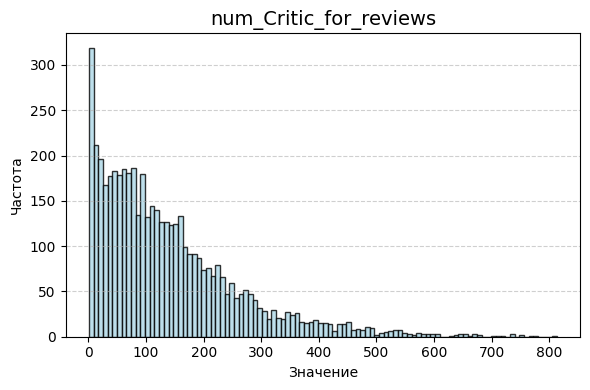

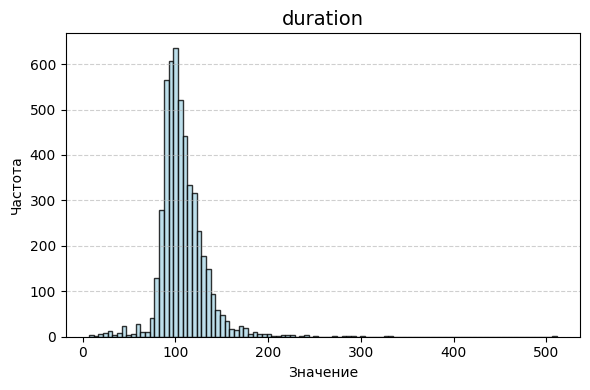

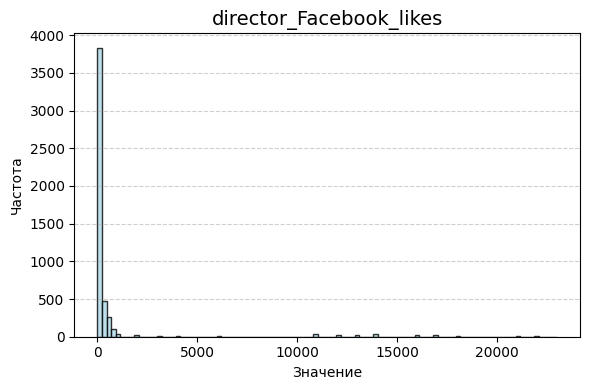

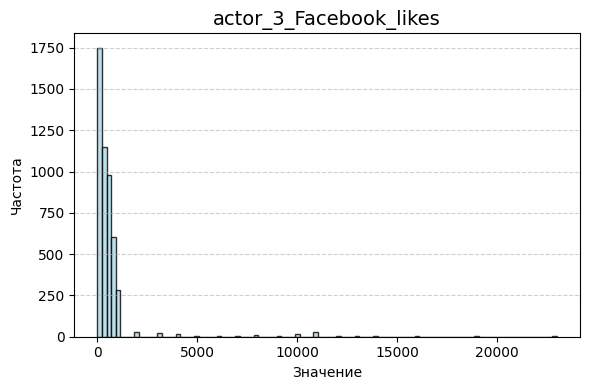

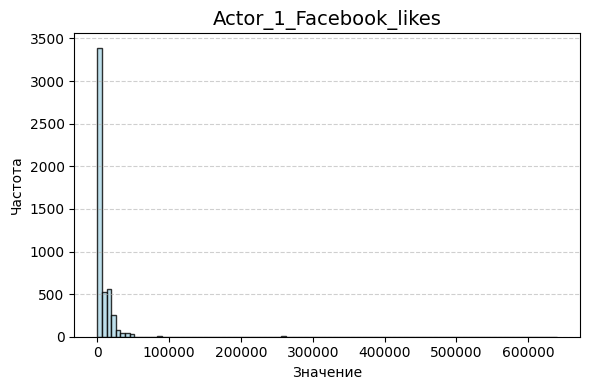

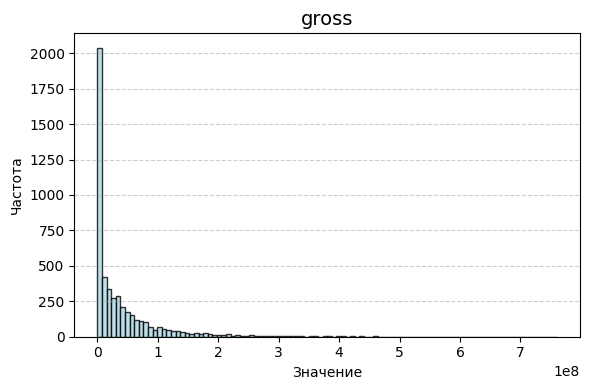

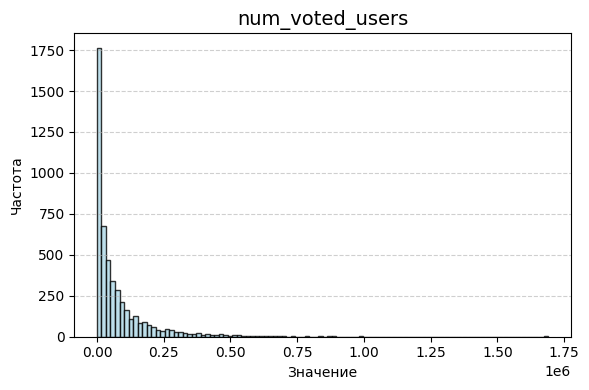

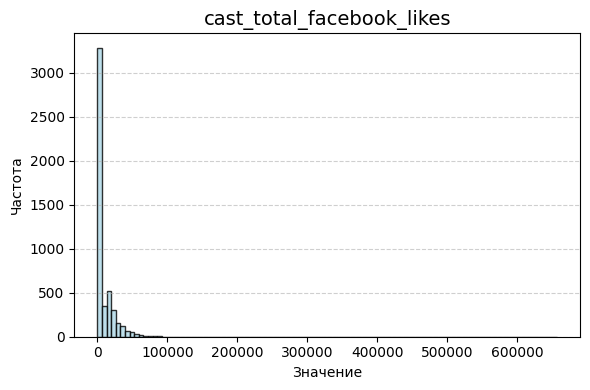

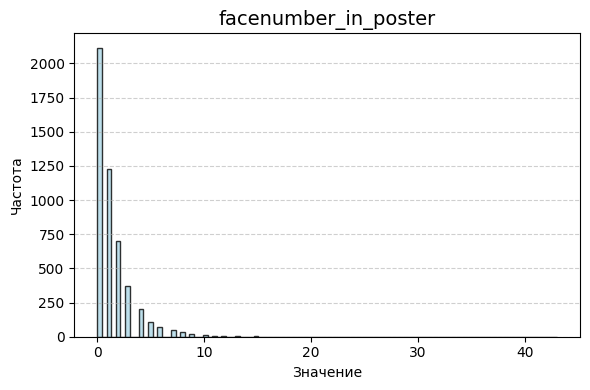

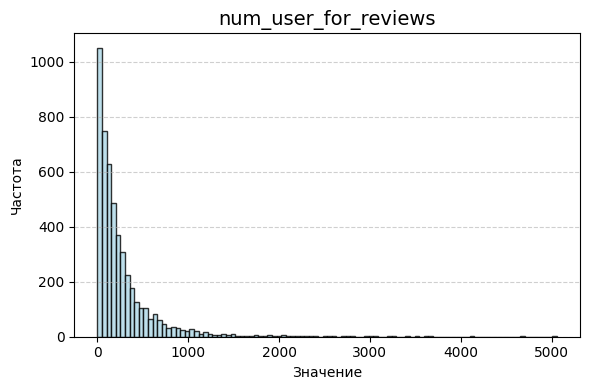

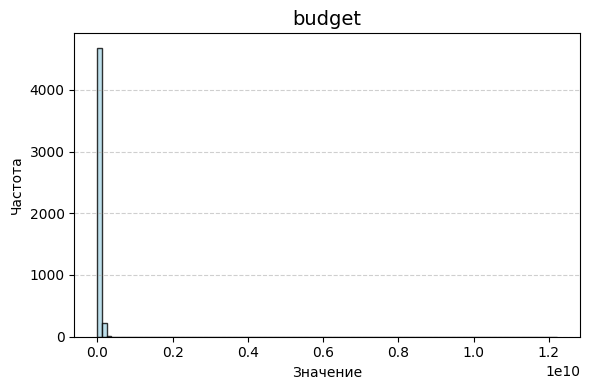

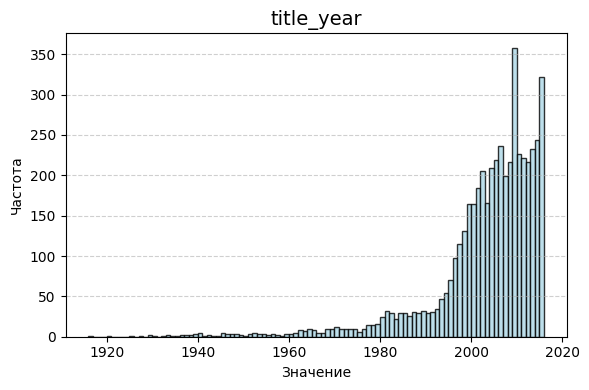

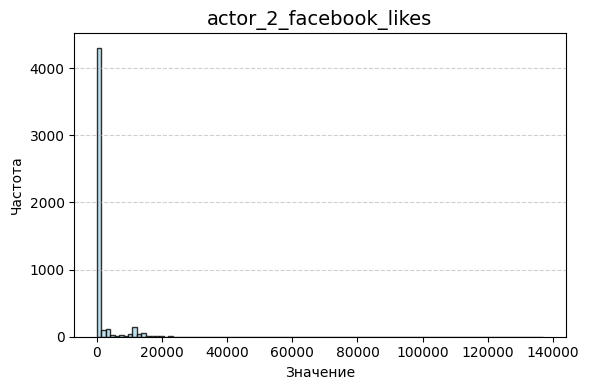

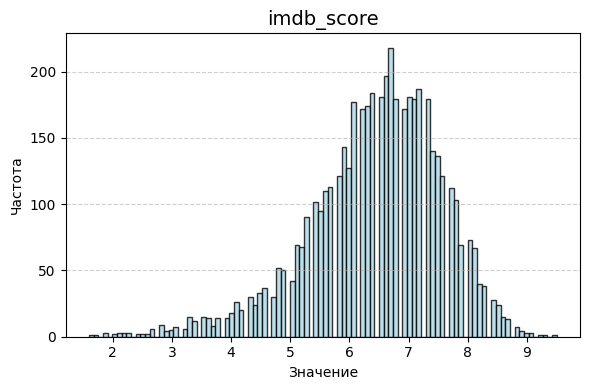

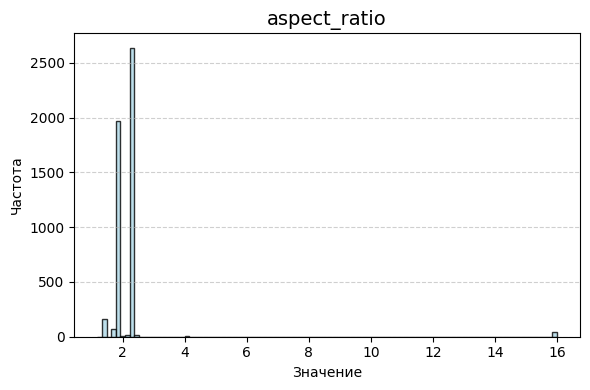

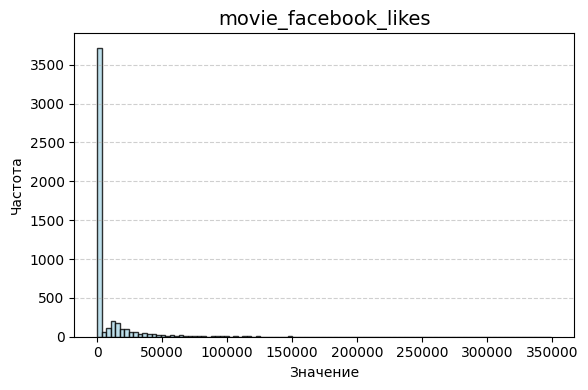

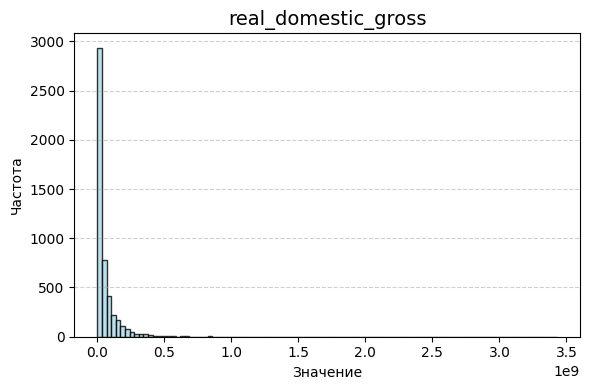

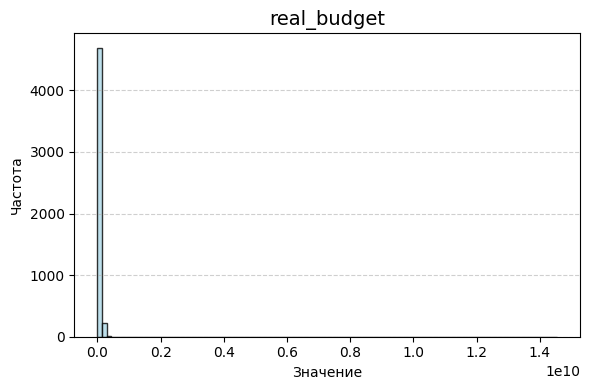

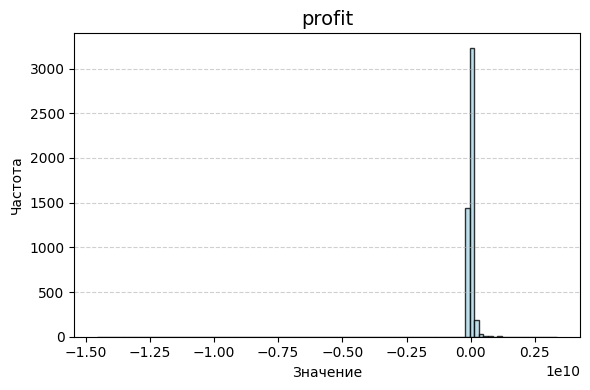

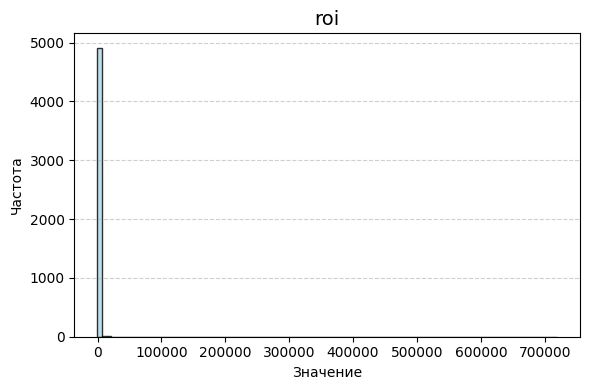

In [22]:
for col in true_numeric:
    plt.figure(figsize=(6, 4))

    plt.hist(
        movies_table[col],
        bins=100,
        color='lightblue',
        edgecolor='black',
        alpha=0.8 
    )

    plt.title(f'{col}', fontsize=14)
    plt.xlabel('Значение')
    plt.ylabel('Частота')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

В числовых признаках `duration`, `imdb_score` удалим выбросы при помощи обрезки по квантилям, в остальных - по персентилям.

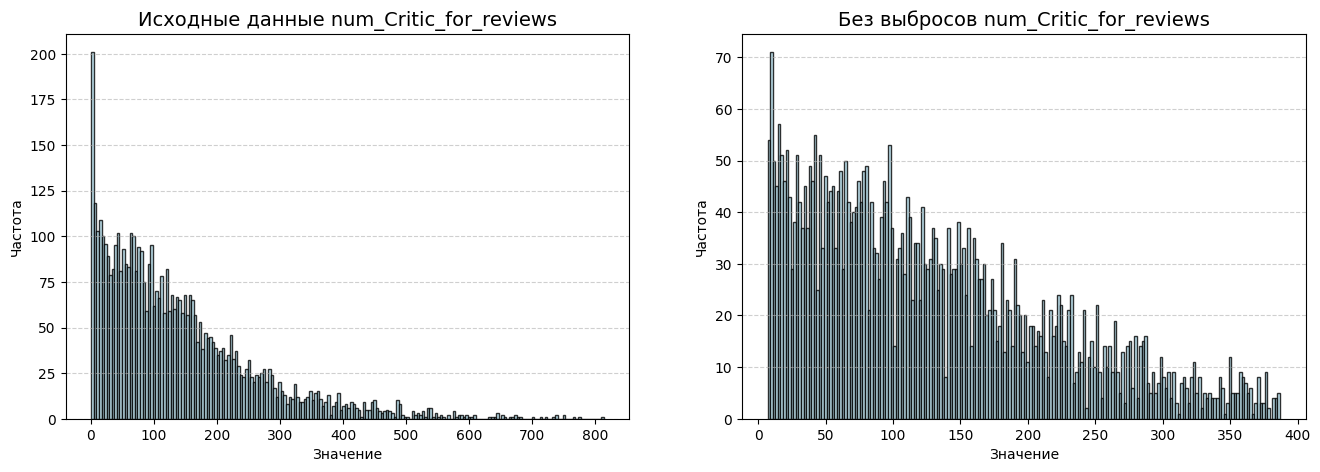

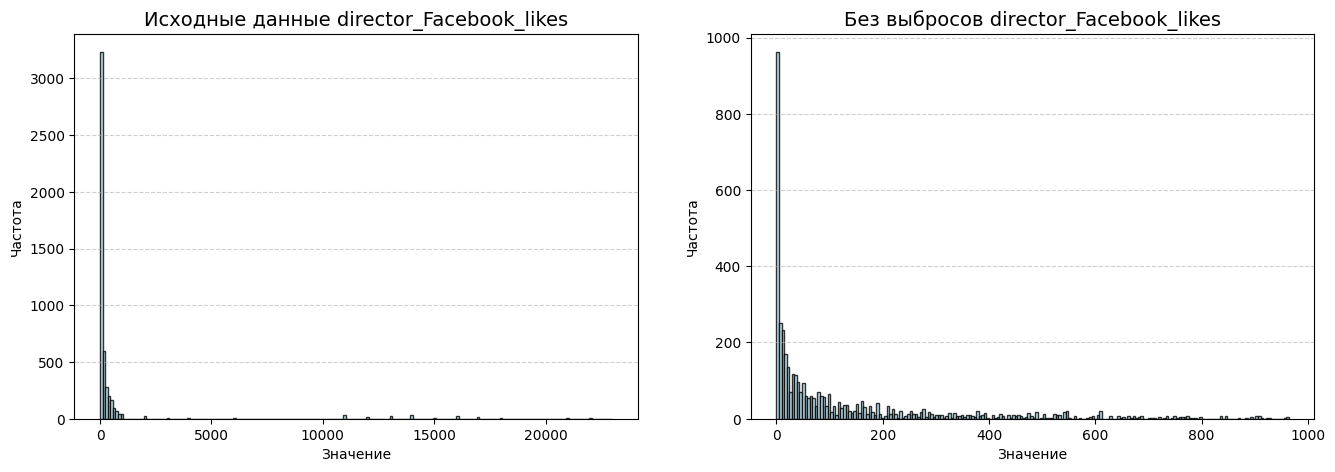

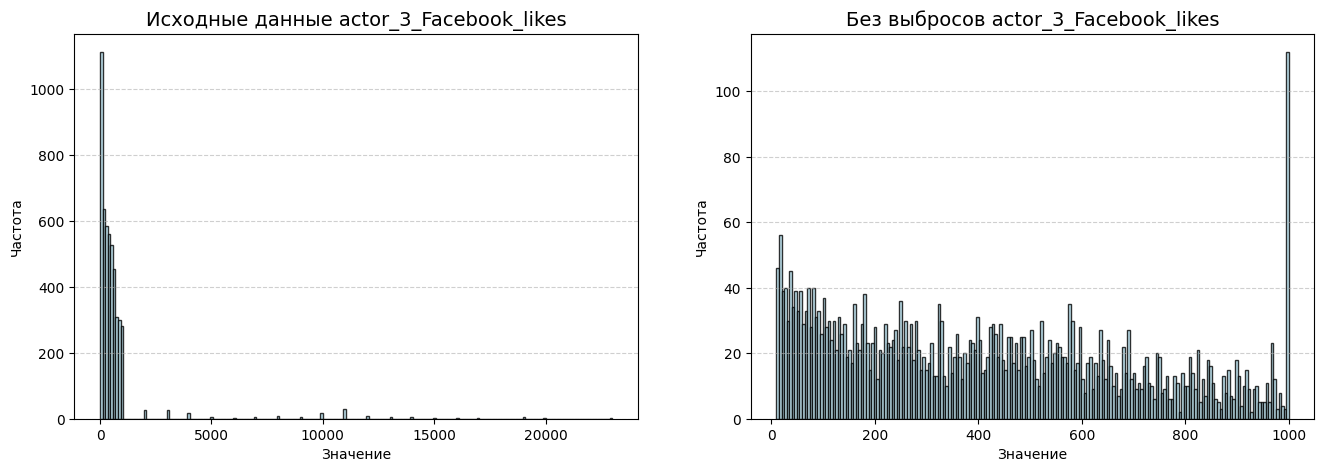

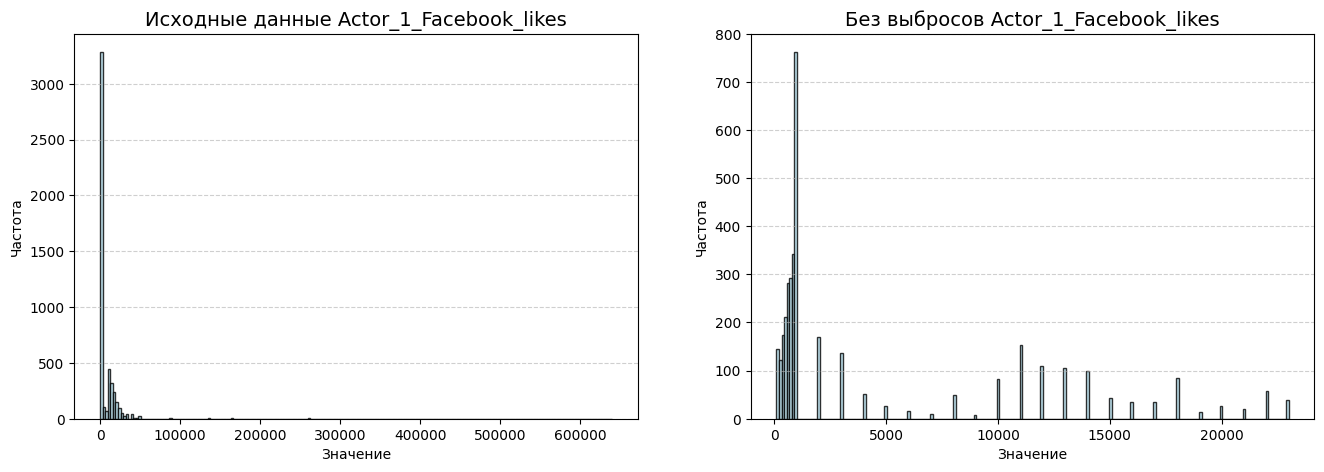

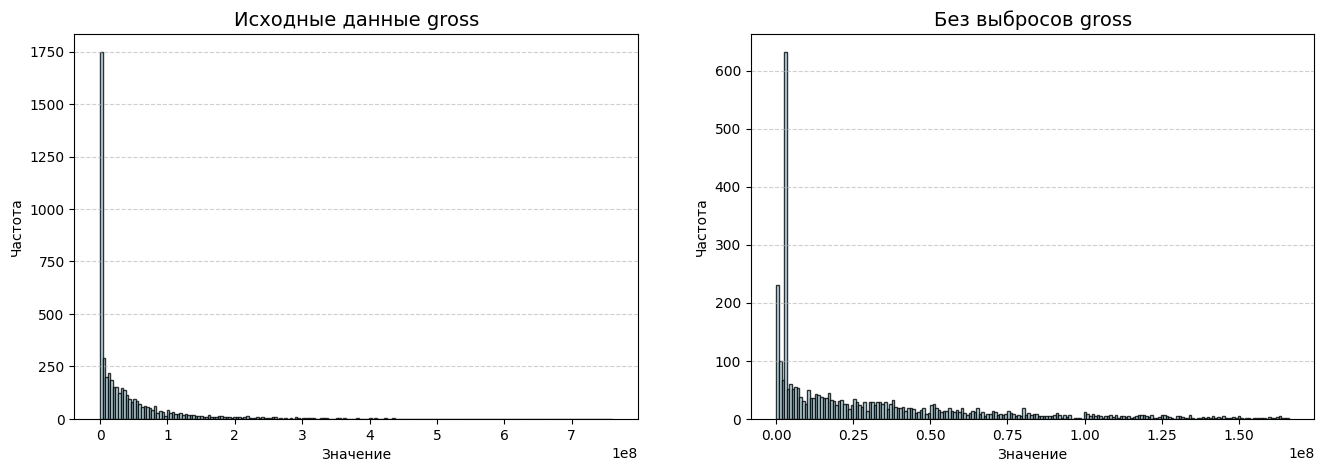

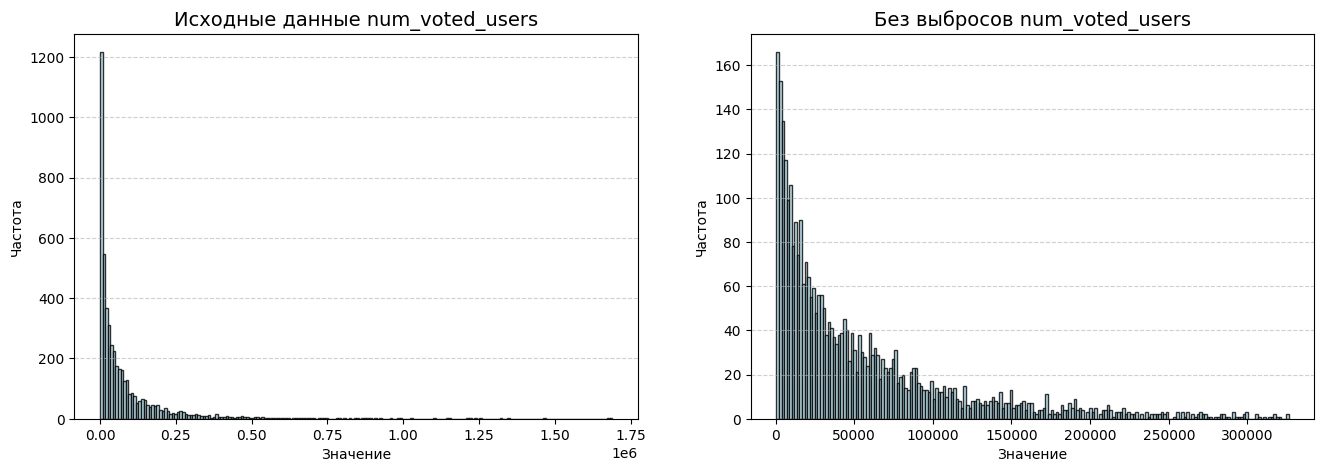

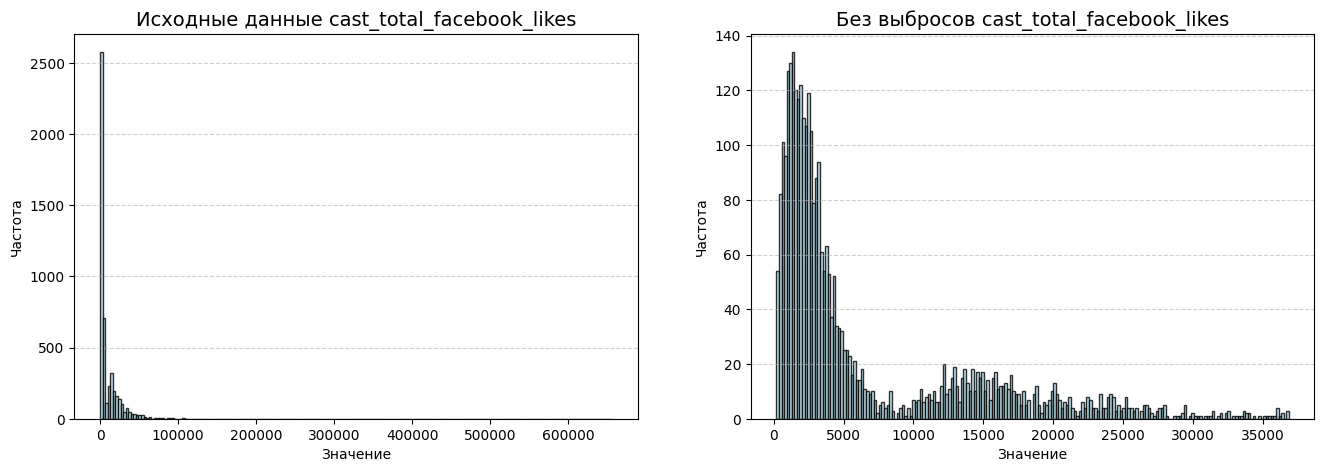

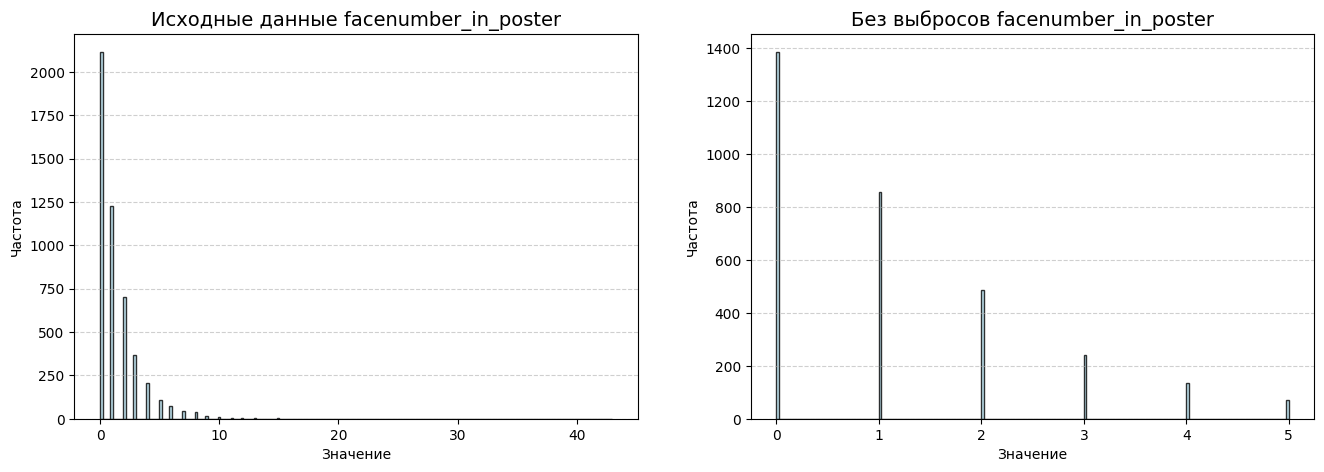

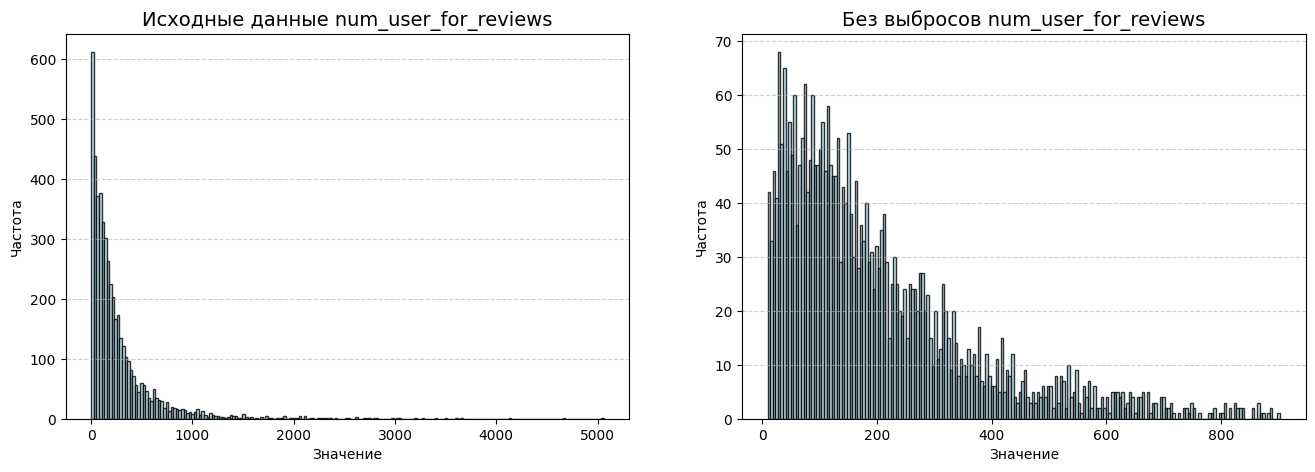

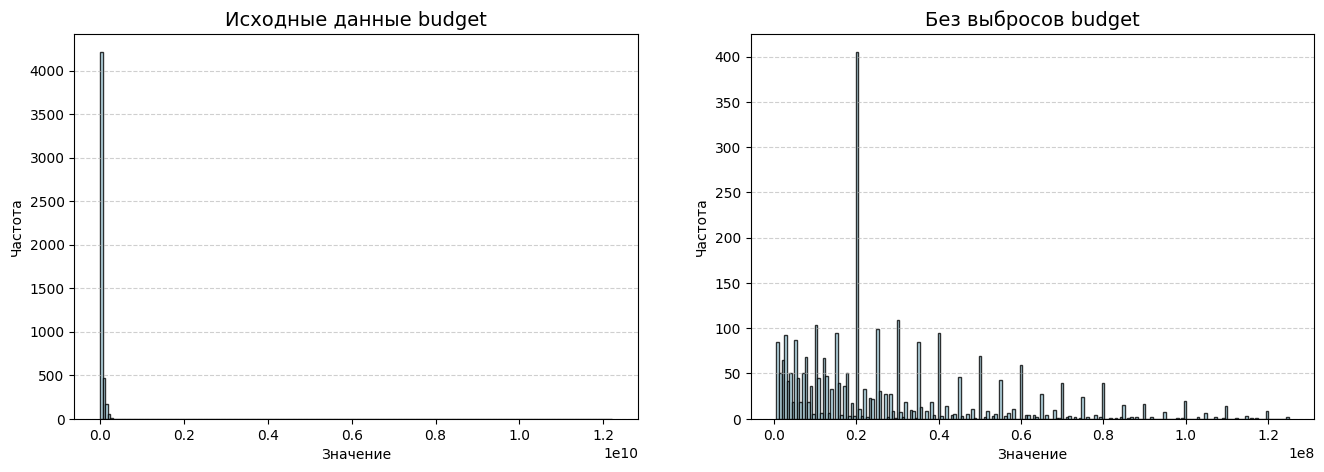

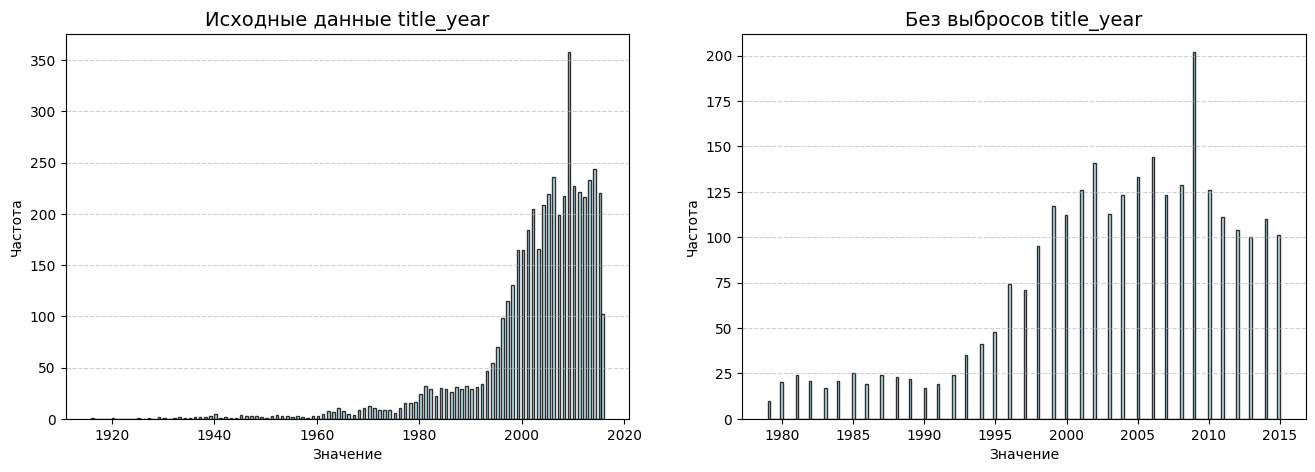

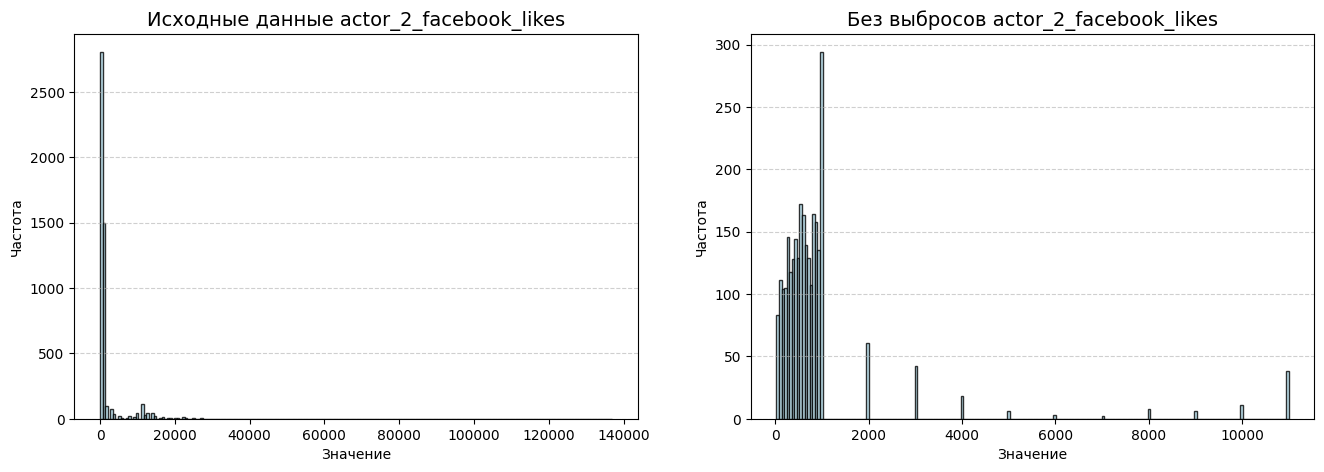

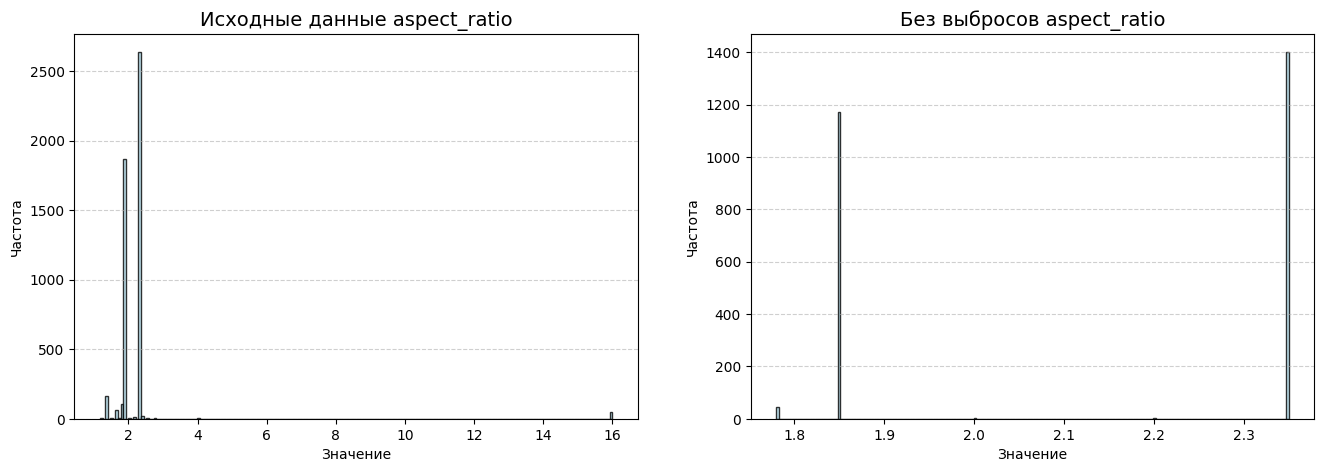

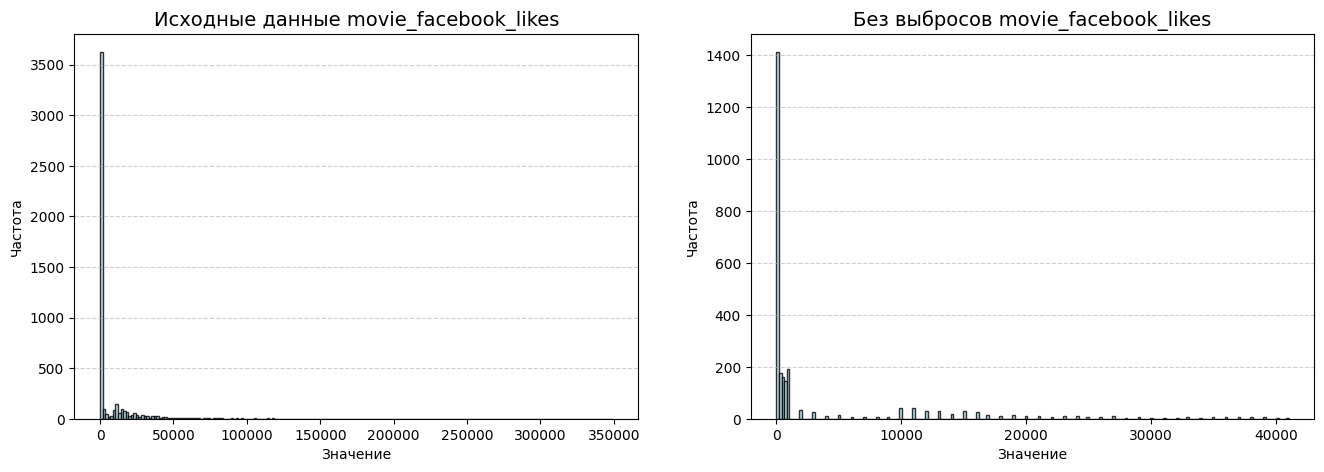

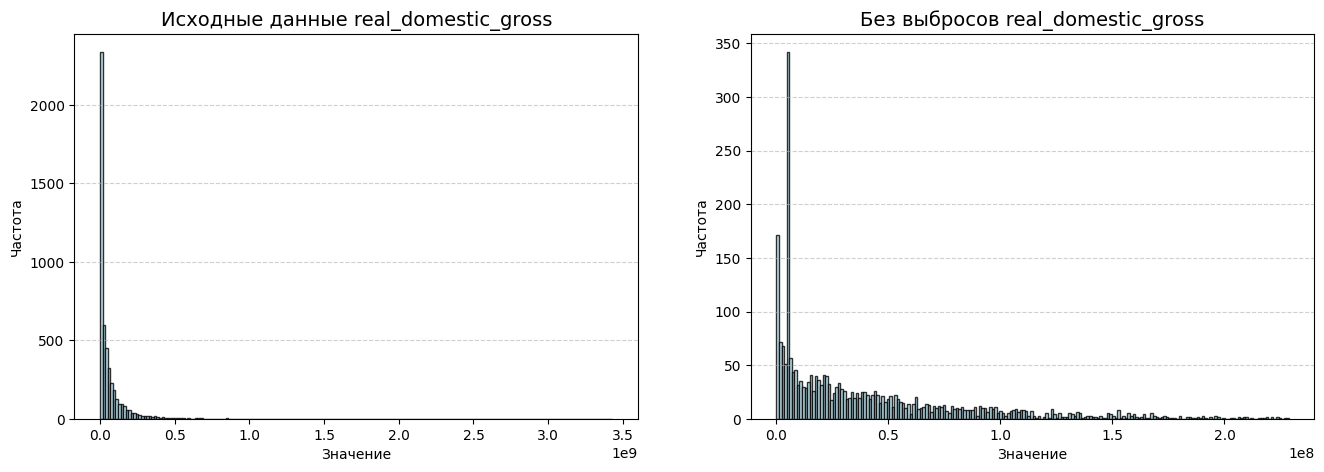

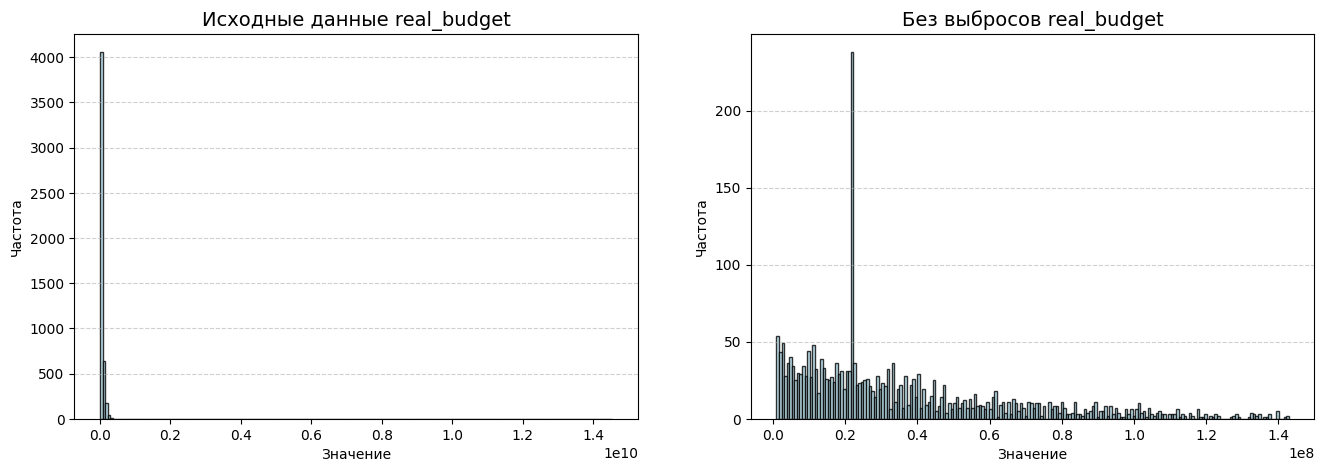

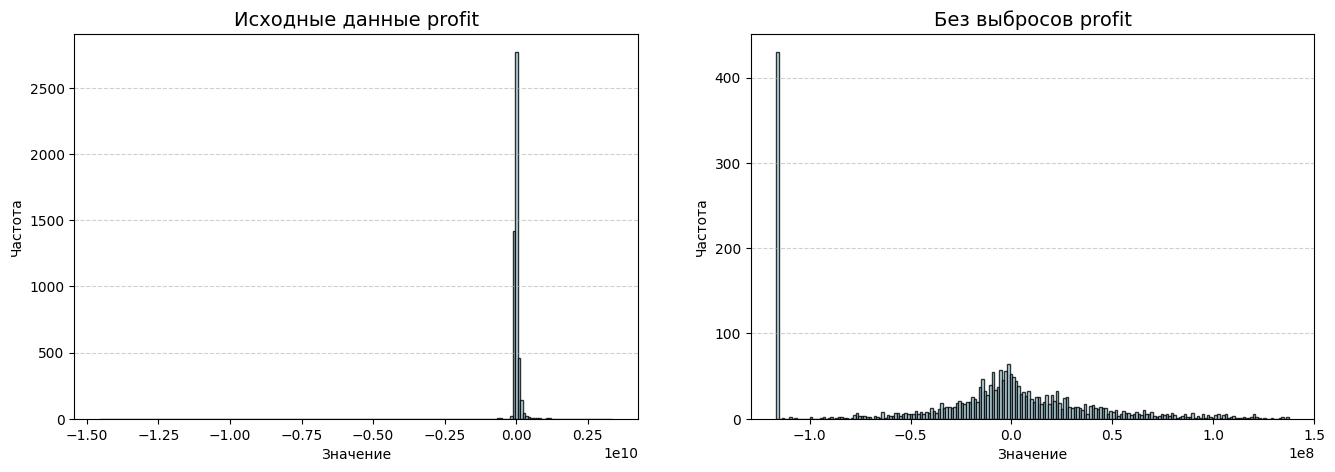

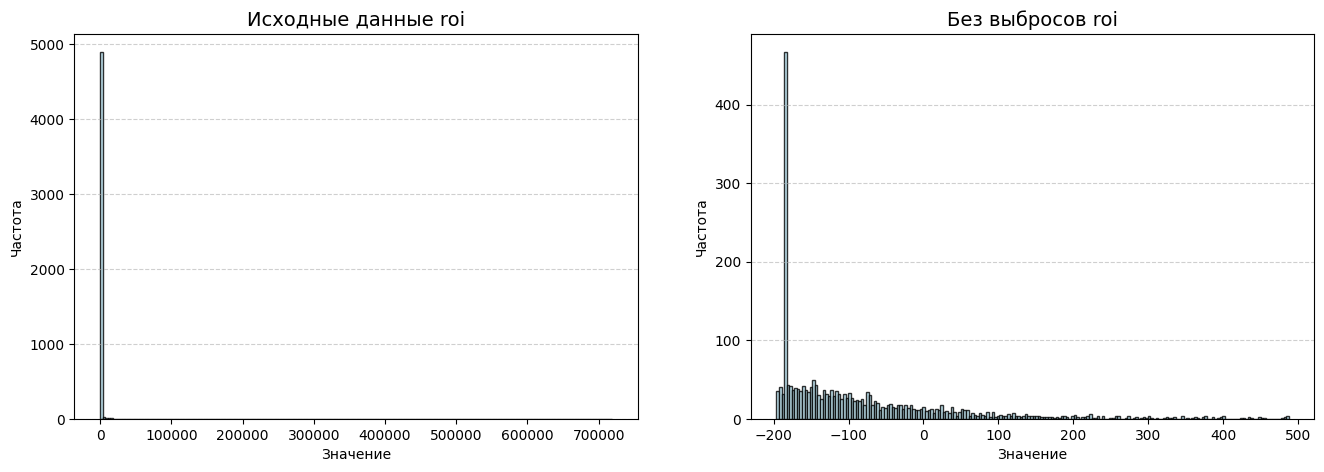

In [23]:
movies_table_filtered = movies_table.copy()

col_for_per = [col for col in true_numeric if col != 'duration' and col != 'imdb_score']

for col in col_for_per:

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].hist(
        movies_table[col],
        bins=200,
        color='lightblue',
        edgecolor='black',
        alpha=0.8
    )
    axes[0].set_title(f'Исходные данные {col}', fontsize=14)
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Частота')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    lower_bound = movies_table[col].quantile(0.05)
    upper_bound = movies_table[col].quantile(0.95)

    movies_table_filtered = movies_table_filtered[(movies_table_filtered[col] >= lower_bound) & (movies_table_filtered[col] <= upper_bound)]

    axes[1].hist(
        movies_table_filtered[col],
        bins=200,
        color='lightblue',
        edgecolor='black',
        alpha=0.8
    )
    axes[1].set_title(f'Без выбросов {col}', fontsize=14)
    axes[1].set_xlabel('Значение')
    axes[1].set_ylabel('Частота')
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)

    plt.show()

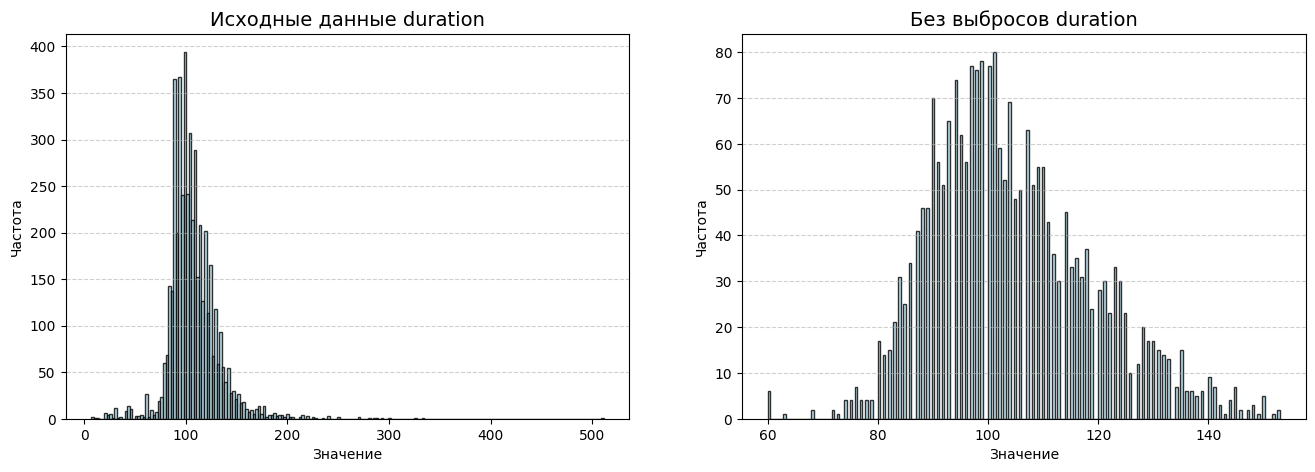

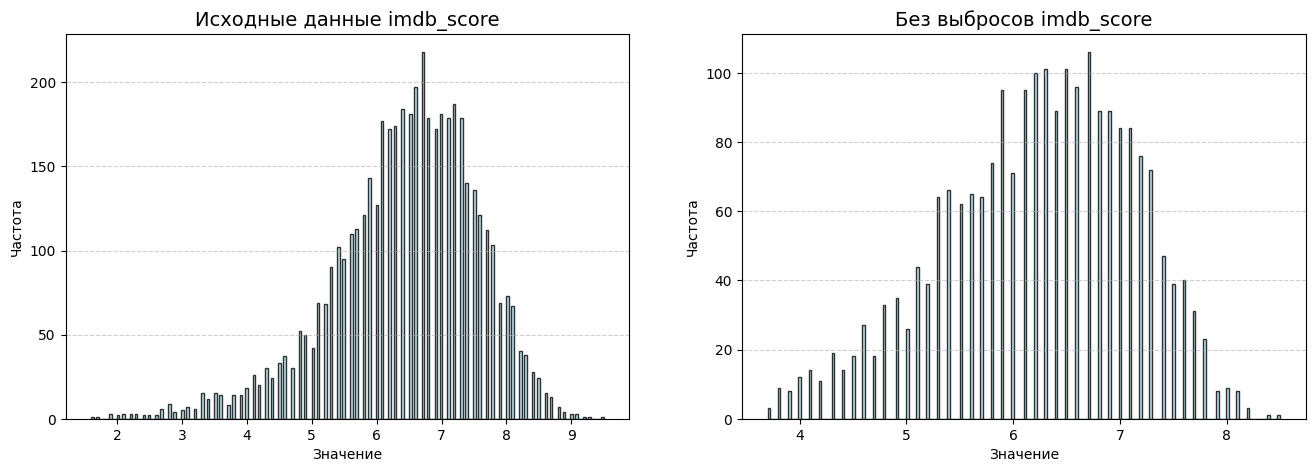

In [24]:
col_for_quan = ['duration', 'imdb_score']

for col in col_for_quan:

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].hist(
        movies_table[col],
        bins=200,
        color='lightblue',
        edgecolor='black',
        alpha=0.8
    )
    axes[0].set_title(f'Исходные данные {col}', fontsize=14)
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Частота')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    Q1 = movies_table[col].quantile(0.25)
    Q3 = movies_table[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    movies_table_filtered = movies_table_filtered[(movies_table_filtered[col] >= lower_bound) & (movies_table_filtered[col] <= upper_bound)]

    axes[1].hist(
        movies_table_filtered[col],
        bins=200,
        color='lightblue',
        edgecolor='black',
        alpha=0.8
    )
    axes[1].set_title(f'Без выбросов {col}', fontsize=14)
    axes[1].set_xlabel('Значение')
    axes[1].set_ylabel('Частота')
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)

    plt.show()

### Визуализации

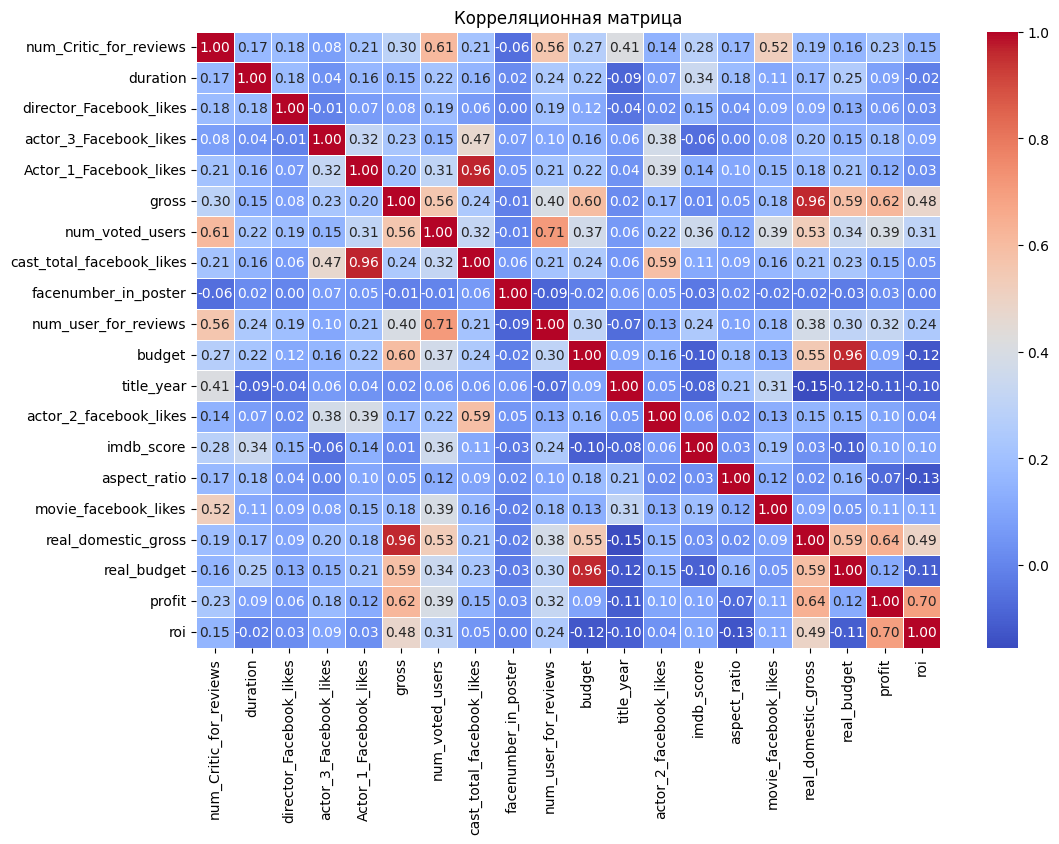

In [25]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(movies_table_filtered[true_numeric].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show()

Можно удалить `gross`, `budget`, тк они не отражают актуальную информацию.

In [26]:
cols_un = ['gross', 'budget']
movies_table_filtered = movies_table_filtered.drop(cols_un, axis=1)
true_numeric = [col for col in true_numeric if col != 'gross' and col != 'budget']

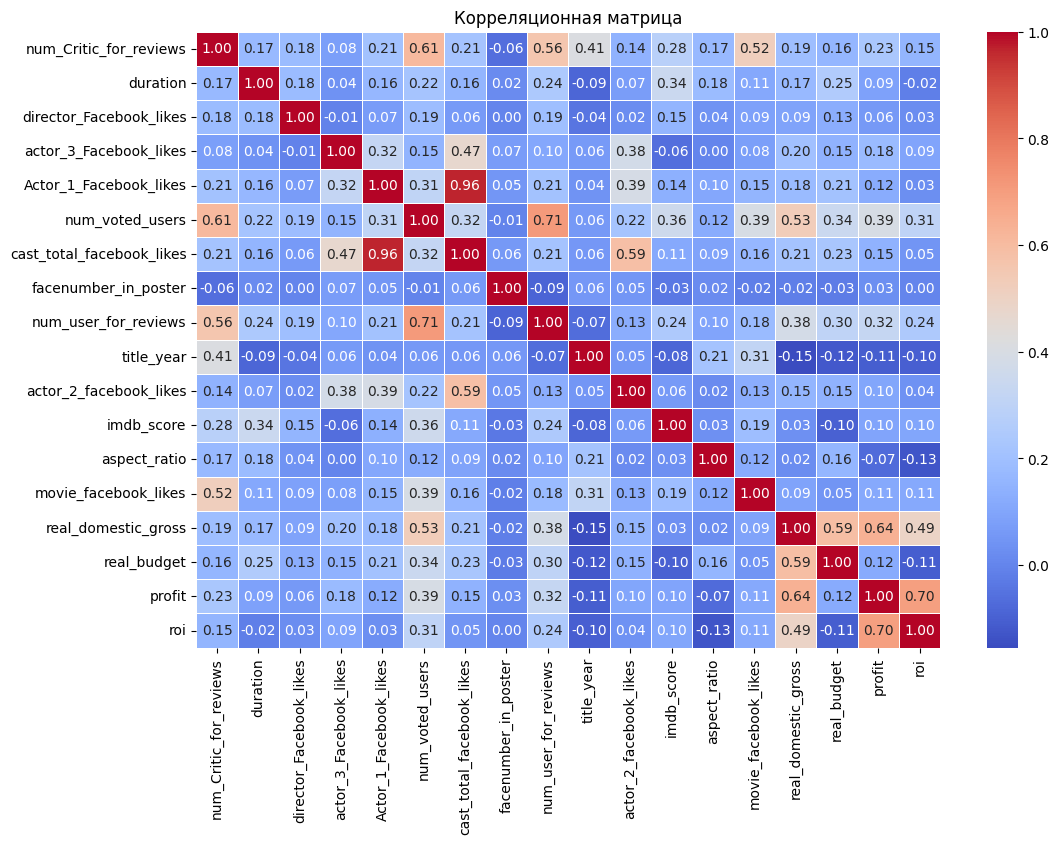

In [27]:
plt.figure(figsize=(12, 8))

sns.heatmap(movies_table_filtered[true_numeric].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show()

#### График scatter plot для сильно коррелирующих пар

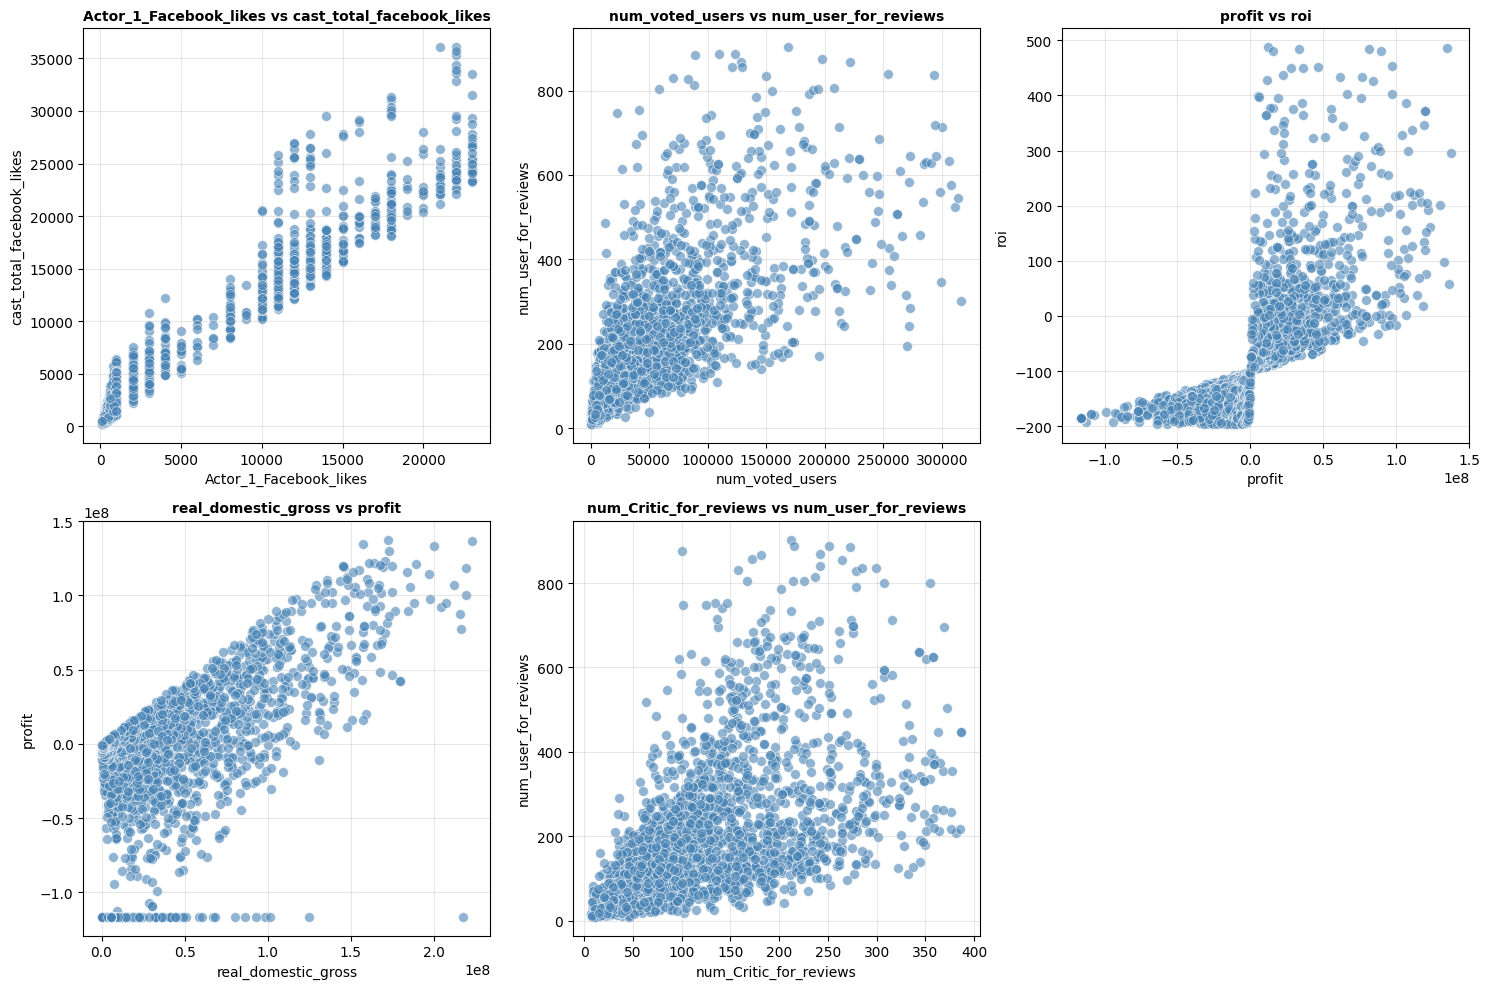

In [28]:
pairs_to_plot = [
    ('Actor_1_Facebook_likes', 'cast_total_facebook_likes'),  
    ('num_voted_users', 'num_user_for_reviews'),            
    ('profit', 'roi'),                                        
    ('real_domestic_gross', 'profit'),                         
    ('num_Critic_for_reviews', 'num_user_for_reviews'),       
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (col1, col2) in enumerate(pairs_to_plot):
    if i < len(axes):
        sns.scatterplot(data=movies_table_filtered, x=col1, y=col2, 
                       alpha=0.6, s=50, ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col1} vs {col2}', fontweight='bold', fontsize=10)
        axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

#### Распределение ключевых числовых признаков

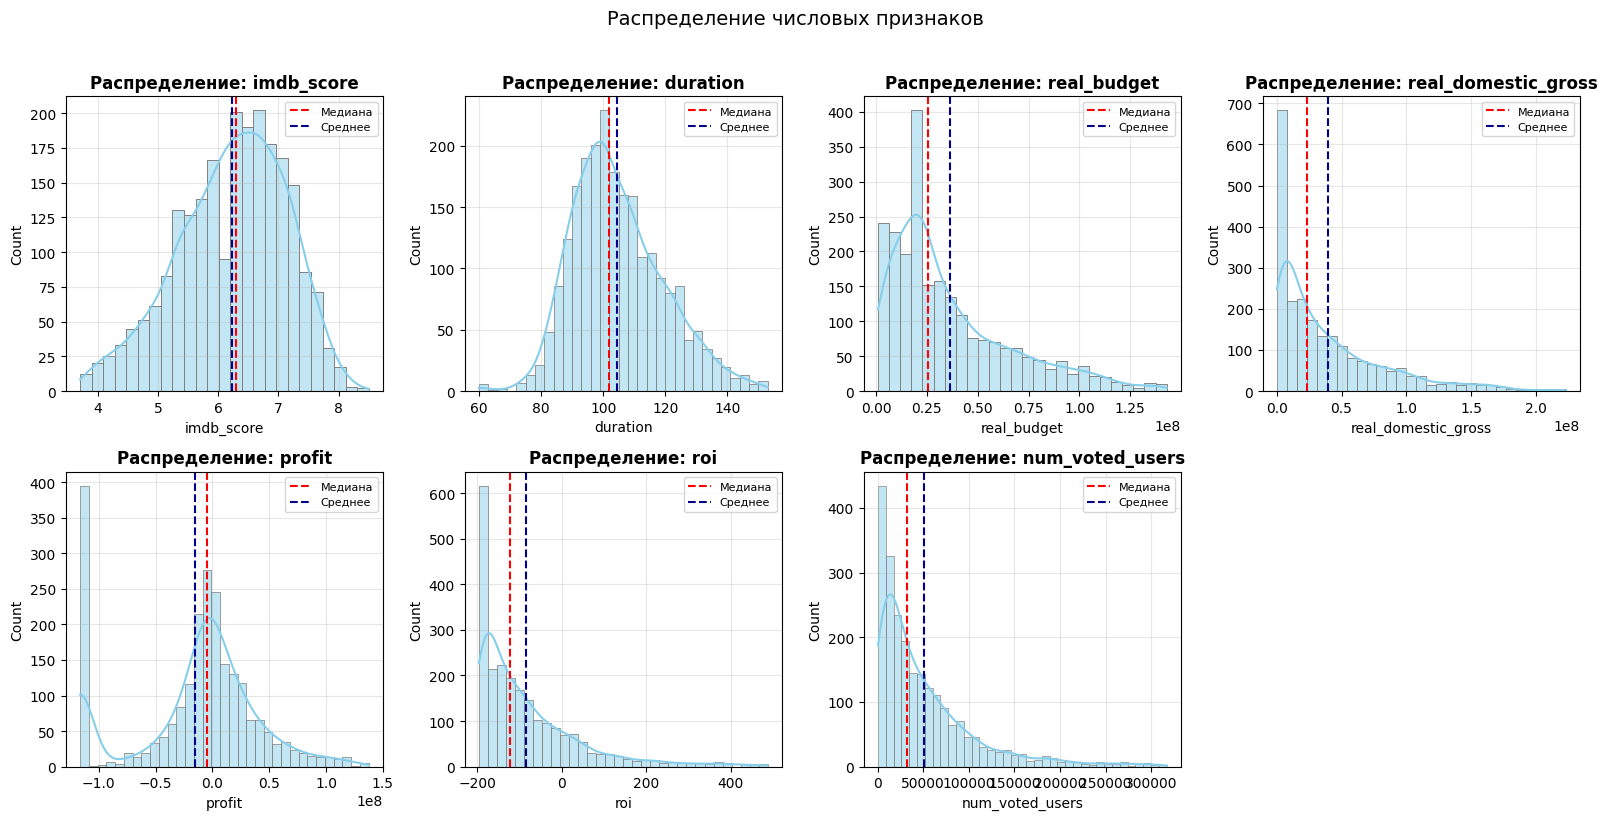

In [29]:
key_numeric = ['imdb_score', 'duration', 'real_budget', 'real_domestic_gross', 
               'profit', 'roi', 'num_voted_users']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    if i < len(axes):
        sns.histplot(data=movies_table_filtered, x=col, kde=True, 
                    ax=axes[i], color='skyblue', edgecolor='gray')
        axes[i].axvline(movies_table_filtered[col].median(), 
                       color='red', linestyle='--', linewidth=1.5, label='Медиана')
        axes[i].axvline(movies_table_filtered[col].mean(), 
                       color='darkblue', linestyle='--', linewidth=1.5, label='Среднее')
        axes[i].set_title(f'Распределение: {col}', fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Распределение числовых признаков', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Взаимосвязь признаков с целевой переменной (например, imdb_score)

Корреляция с imdb_score:
num_voted_users              0.357331
duration                     0.343563
num_Critic_for_reviews       0.278443
num_user_for_reviews         0.243733
movie_facebook_likes         0.190317
director_Facebook_likes      0.153047
Actor_1_Facebook_likes       0.135071
cast_total_facebook_likes    0.111774
roi                          0.098824
real_budget                  0.097605
Name: imdb_score, dtype: float64


/var/folders/3t/nrh9s4r13w7ddm0z55q4kcxm0000gn/T/ipykernel_37021/2894320094.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features, y=corr_with_target.head(8).values,


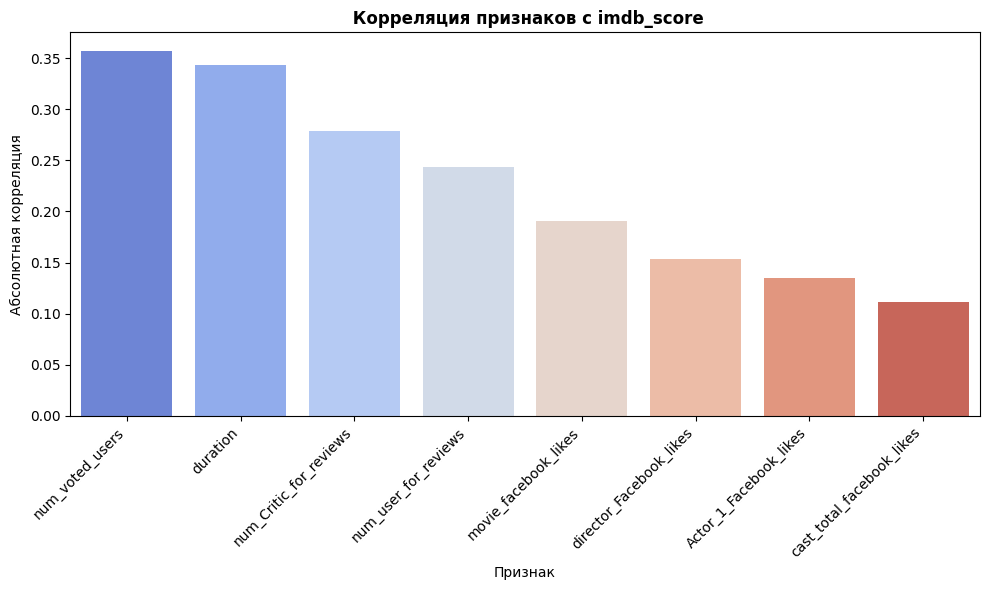

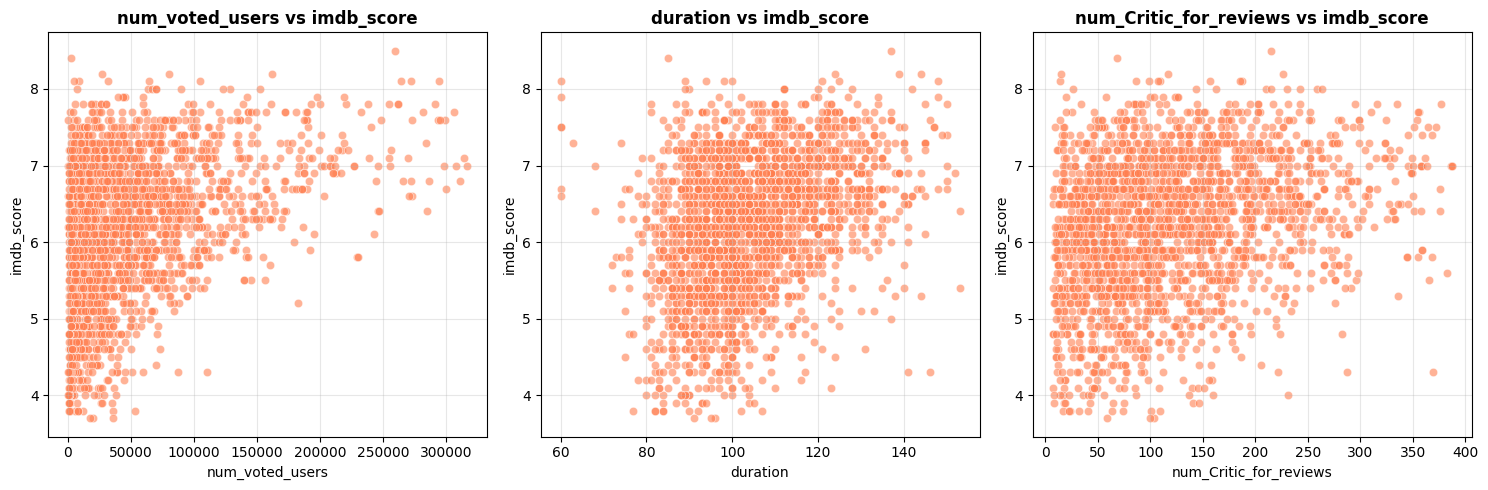

In [30]:
target = 'imdb_score'

corr_with_target = movies_table_filtered[true_numeric].corr()[target].drop(target).abs().sort_values(ascending=False)

print("Корреляция с imdb_score:")
print(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
top_features = corr_with_target.head(8).index
sns.barplot(x=top_features, y=corr_with_target.head(8).values, 
           palette='coolwarm')
plt.title(' Корреляция признаков с imdb_score', fontweight='bold', fontsize=12)
plt.xlabel('Признак')
plt.ylabel('Абсолютная корреляция')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(corr_with_target.head(3).index):
    sns.scatterplot(data=movies_table_filtered, x=col, y=target, 
                   alpha=0.6, ax=axes[i], color='coral')
    axes[i].set_title(f'{col} vs {target}', fontweight='bold')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Анализ жанров


Влияние жанров на imdb_score:
      genre  avg_score_with_genre  avg_score_without  difference  count
       News                  7.40               6.23        1.17      1
Documentary                  7.08               6.22        0.86     16
  Biography                  7.01               6.18        0.82    124
        War                  6.91               6.21        0.70     62
      Drama                  6.57               5.87        0.70   1177
    History                  6.89               6.21        0.69     67
    Western                  6.50               6.22        0.27     34
      Sport                  6.48               6.22        0.26     92
      Music                  6.39               6.22        0.17    104
      Crime                  6.32               6.20        0.12    471
    Romance                  6.27               6.21        0.06    572
    Musical                  6.26               6.23        0.03     46
  Animation                  6.25

/var/folders/3t/nrh9s4r13w7ddm0z55q4kcxm0000gn/T/ipykernel_37021/2162775630.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='genre', y='difference', palette='coolwarm')


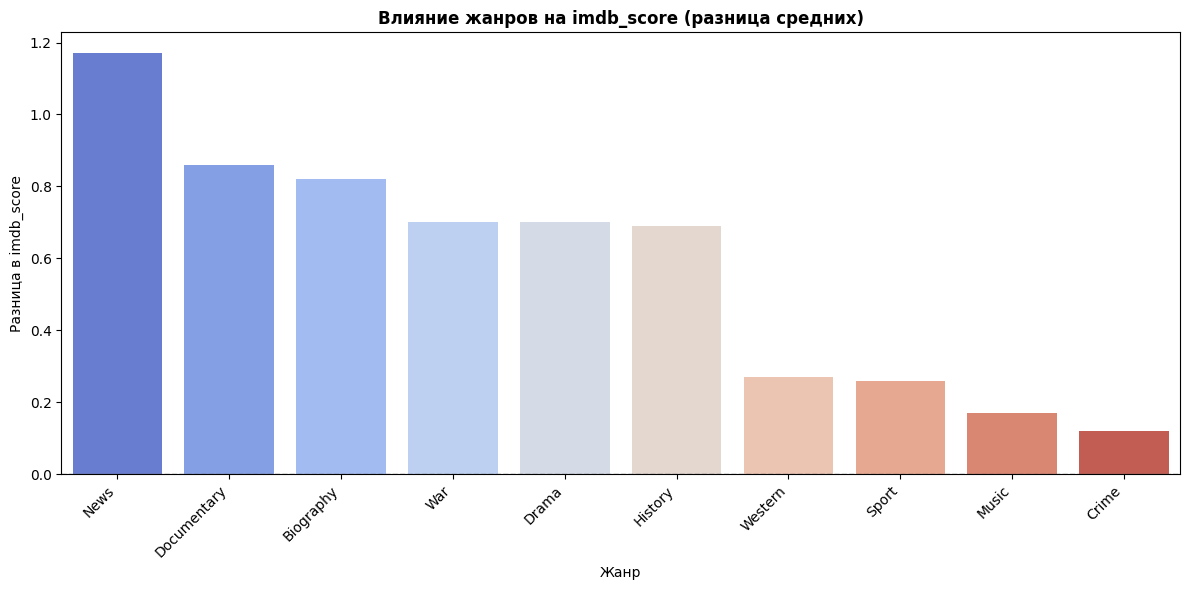

In [33]:

genre_cols = [col for col in movies_table_filtered.columns if col.startswith('genre_')]
if genre_cols and 'imdb_score' in movies_table_filtered.columns:
    genre_impact = []
    
    for genre in genre_cols:
        genre_name = genre.replace('genre_', '')
        avg_score_with = movies_table_filtered[movies_table_filtered[genre] == 1]['imdb_score'].mean()
        avg_score_without = movies_table_filtered[movies_table_filtered[genre] == 0]['imdb_score'].mean()
        count = movies_table_filtered[genre].sum()
        
        genre_impact.append({
            'genre': genre_name,
            'avg_score_with_genre': round(avg_score_with, 2),
            'avg_score_without': round(avg_score_without, 2),
            'difference': round(avg_score_with - avg_score_without, 2),
            'count': int(count)
        })
    
    genre_df = pd.DataFrame(genre_impact).sort_values('difference', ascending=False)
    
    print("\nВлияние жанров на imdb_score:")
    print(genre_df.to_string(index=False))
    
    plt.figure(figsize=(12, 6))
    top_genres = genre_df.head(10)
    sns.barplot(data=top_genres, x='genre', y='difference', palette='coolwarm')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.title('Влияние жанров на imdb_score (разница средних)', fontweight='bold')
    plt.xlabel('Жанр')
    plt.ylabel('Разница в imdb_score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Ответы на вопросы

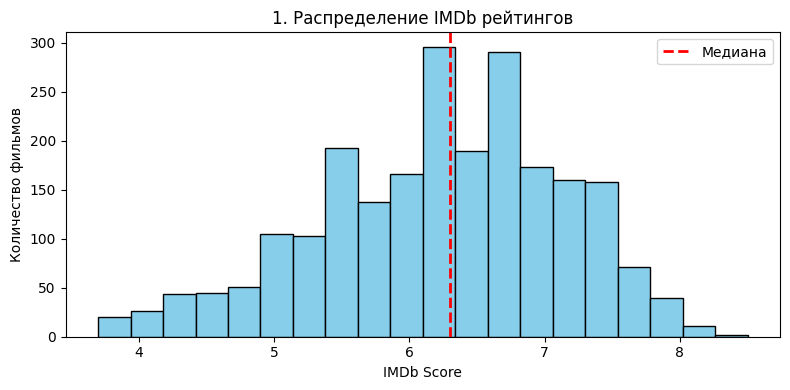

ОТВЕТ: Рейтинги распределены нормально. Медиана: 6.30. Большинство фильмов имеют рейтинг 6.0-7.5.



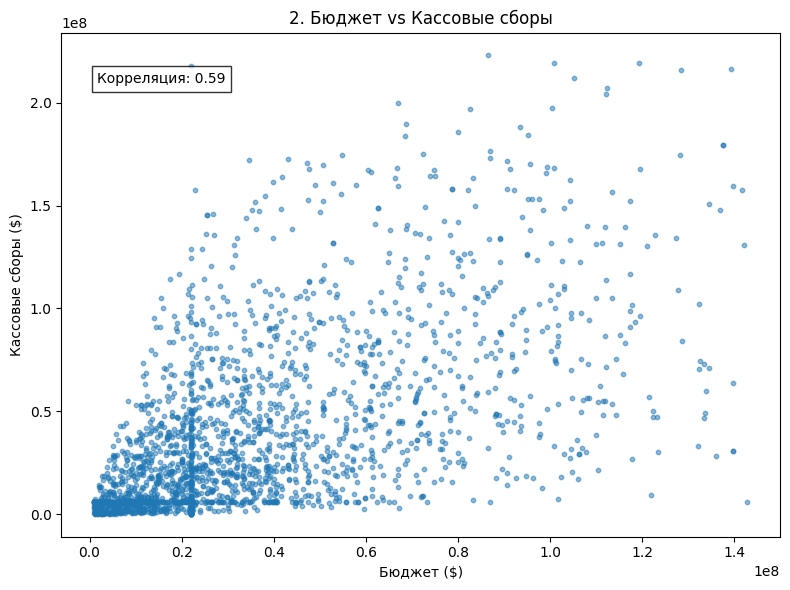

ОТВЕТ: Да, существует положительная зависимость (корреляция 0.59). Чем выше бюджет, тем выше кассовые сборы.



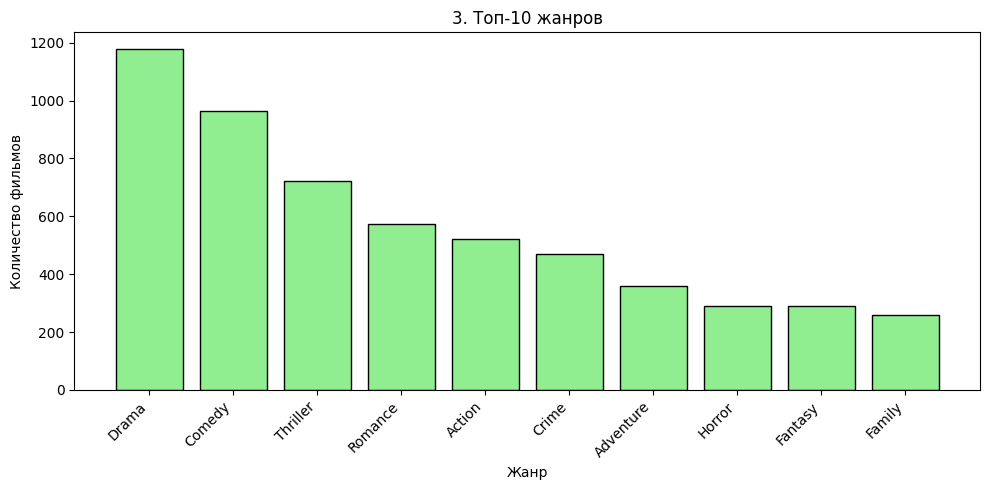

ОТВЕТ: Чаще всего встречаются: Drama (1177 фильмов), Comedy (965), Thriller (722).



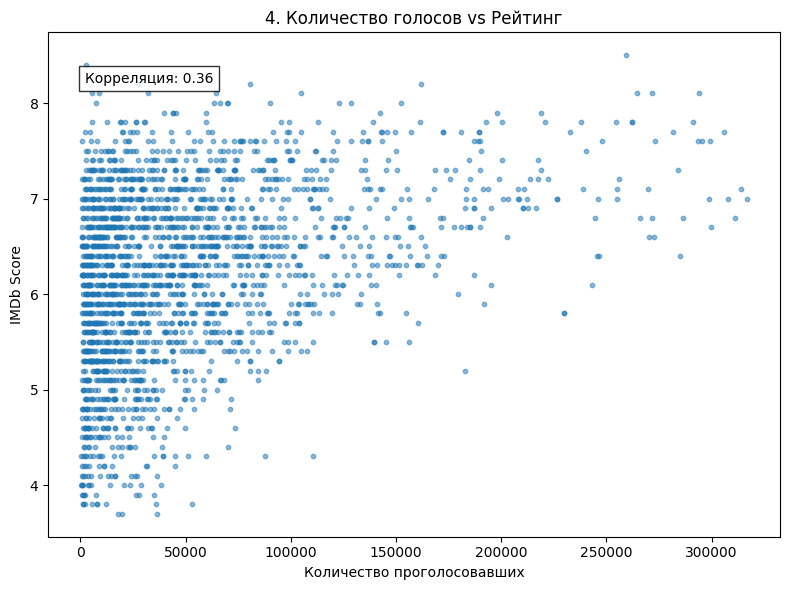

ОТВЕТ: Да влияет. Корреляция: 0.36. Более популярные фильмы имеют более высокий рейтинг.



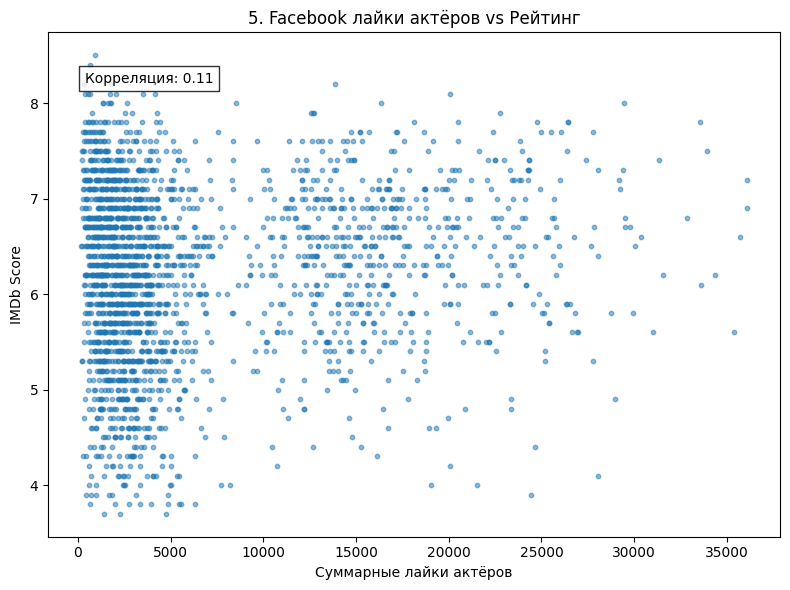

ОТВЕТ: Есть слабая. Корреляция: 0.11. Популярность актёров в Facebook не сильно связана с качеством фильма.



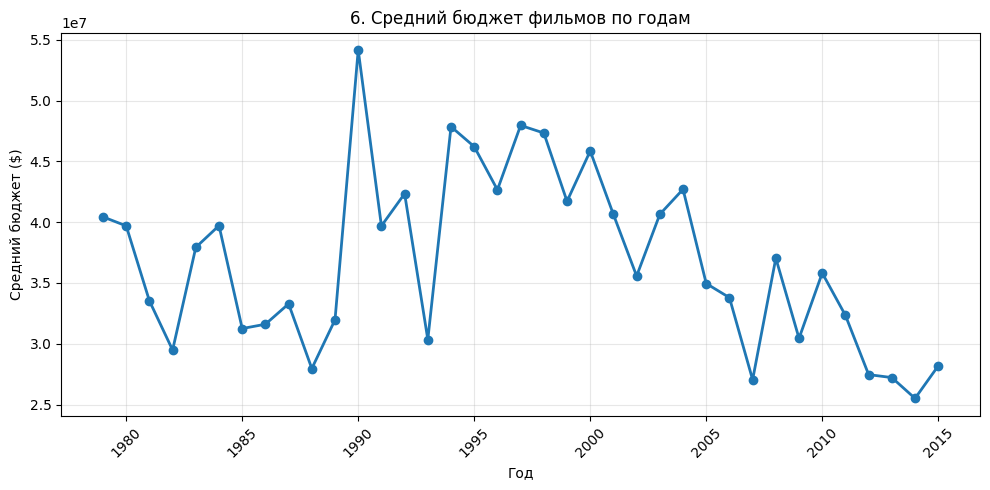

ОТВЕТ: Бюджет падал с течением времени. В 1979 году: $40,438,717, в 2015 году: $28,180,694.



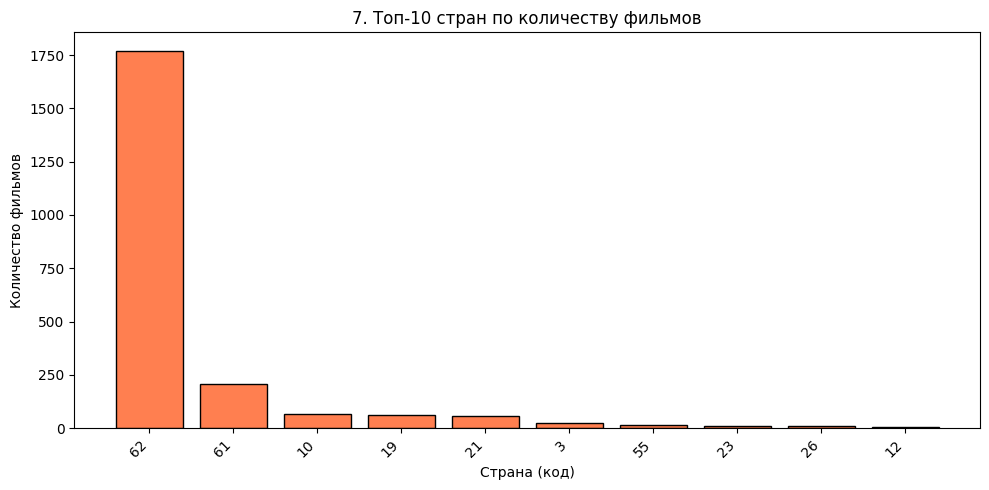

ОТВЕТ: Лидирует USA (1768 фильмов), далее UK (209), France (66).



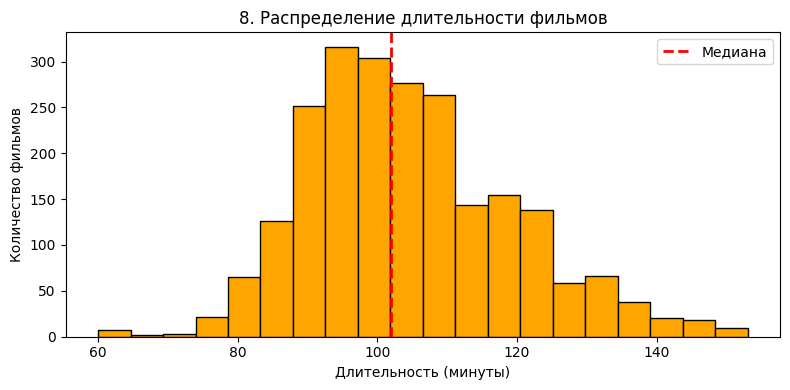

ОТВЕТ: Средняя длительность: 105 минут. Медиана: 102 минут. Большинство фильмов длятся 90-120 минут.



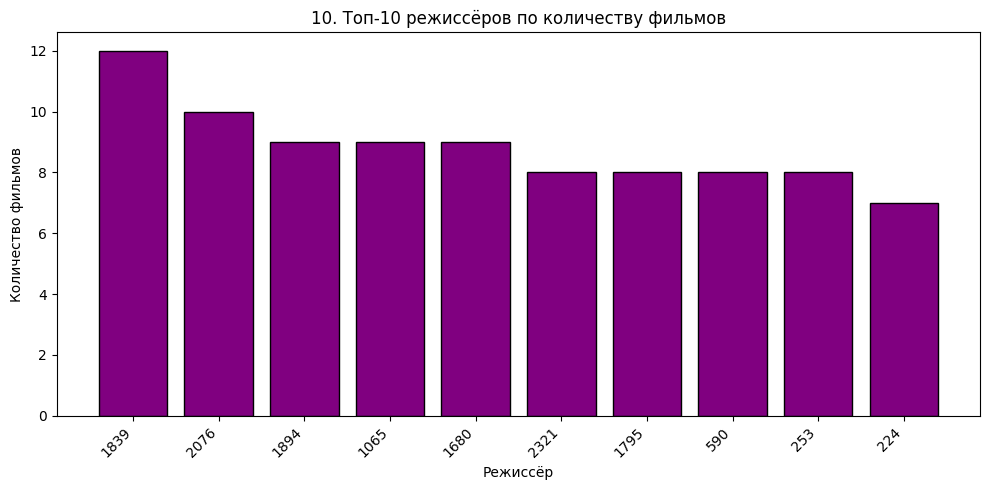

ОТВЕТ: Больше всего фильмов снял 1839 (12 фильмов), далее 2076 (10), 1894 (9).



In [35]:
plt.style.use('default')


# 1. Как распределены рейтинги фильмов (IMDb score)?

plt.figure(figsize=(8, 4))
plt.hist(movies_table_filtered['imdb_score'].dropna(), bins=20, edgecolor='black', color='skyblue')
plt.title('1. Распределение IMDb рейтингов')
plt.xlabel('IMDb Score')
plt.ylabel('Количество фильмов')
plt.axvline(movies_table_filtered['imdb_score'].median(), color='red', linestyle='--', linewidth=2, label='Медиана')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: Рейтинги распределены нормально. Медиана: {movies_table_filtered['imdb_score'].median():.2f}. "
      f"Большинство фильмов имеют рейтинг 6.0-7.5.\n")


# 2. Существует ли зависимость между бюджетом фильма и его кассовыми сборами?

plt.figure(figsize=(8, 6))
plt.scatter(movies_table_filtered['real_budget'], movies_table_filtered['real_domestic_gross'], alpha=0.5, s=10)
plt.title('2. Бюджет vs Кассовые сборы')
plt.xlabel('Бюджет ($)')
plt.ylabel('Кассовые сборы ($)')
corr = movies_table_filtered['real_budget'].corr(movies_table_filtered['real_domestic_gross'])
plt.text(0.05, 0.9, f'Корреляция: {corr:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: Да, существует положительная зависимость (корреляция {corr:.2f}). "
      f"Чем выше бюджет, тем выше кассовые сборы.\n")



# 3. Какие жанры встречаются чаще всего?

genre_cols = [col for col in movies_table_filtered.columns if col.startswith('genre_')]
genre_counts = movies_table_filtered[genre_cols].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(range(len(genre_counts)), genre_counts.values, color='lightgreen', edgecolor='black')
plt.xticks(range(len(genre_counts)), [g.replace('genre_', '') for g in genre_counts.index], rotation=45, ha='right')
plt.title('3. Топ-10 жанров')
plt.xlabel('Жанр')
plt.ylabel('Количество фильмов')
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: Чаще всего встречаются: {genre_counts.index[0].replace('genre_', '')} ({genre_counts.values[0]} фильмов), "
      f"{genre_counts.index[1].replace('genre_', '')} ({genre_counts.values[1]}), "
      f"{genre_counts.index[2].replace('genre_', '')} ({genre_counts.values[2]}).\n")



# 4. Влияет ли количество проголосовавших пользователей на итоговый рейтинг?

plt.figure(figsize=(8, 6))
plt.scatter(movies_table_filtered['num_voted_users'], movies_table_filtered['imdb_score'], alpha=0.5, s=10)
plt.title('4. Количество голосов vs Рейтинг')
plt.xlabel('Количество проголосовавших')
plt.ylabel('IMDb Score')
corr = movies_table_filtered['num_voted_users'].corr(movies_table_filtered['imdb_score'])
plt.text(0.05, 0.9, f'Корреляция: {corr:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: {'Да' if abs(corr) > 0.3 else 'Слабо'} влияет. Корреляция: {corr:.2f}. "
      f"{'Более популярные фильмы имеют более высокий рейтинг.' if corr > 0 else ''}\n")



# 5. Есть ли связь между суммарными лайками актёров в Facebook и рейтингом фильма?

plt.figure(figsize=(8, 6))
plt.scatter(movies_table_filtered['cast_total_facebook_likes'], movies_table_filtered['imdb_score'], alpha=0.5, s=10)
plt.title('5. Facebook лайки актёров vs Рейтинг')
plt.xlabel('Суммарные лайки актёров')
plt.ylabel('IMDb Score')
corr = movies_table_filtered['cast_total_facebook_likes'].corr(movies_table_filtered['imdb_score'])
plt.text(0.05, 0.9, f'Корреляция: {corr:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: {'Есть слабая' if abs(corr) < 0.3 else 'Есть'}. Корреляция: {corr:.2f}. "
      f"Популярность актёров в Facebook {'не сильно' if abs(corr) < 0.3 else ''} связана с качеством фильма.\n")



# 6. Как изменялся средний бюджет фильмов по годам?

yearly_budget = movies_table_filtered.groupby('title_year')['real_budget'].mean().reset_index()
yearly_budget = yearly_budget.dropna()

plt.figure(figsize=(10, 5))
plt.plot(yearly_budget['title_year'], yearly_budget['real_budget'], marker='o', linewidth=2)
plt.title('6. Средний бюджет фильмов по годам')
plt.xlabel('Год')
plt.ylabel('Средний бюджет ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: Бюджет {'рос' if yearly_budget['real_budget'].iloc[-1] > yearly_budget['real_budget'].iloc[0] else 'падал'} "
      f"с течением времени. В {int(yearly_budget['title_year'].iloc[0])} году: ${yearly_budget['real_budget'].iloc[0]:,.0f}, "
      f"в {int(yearly_budget['title_year'].iloc[-1])} году: ${yearly_budget['real_budget'].iloc[-1]:,.0f}.\n")


# 7. Какие страны лидируют по количеству произведённых фильмов?

country_counts = movies_table_filtered['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(range(len(country_counts)), country_counts.values, color='coral', edgecolor='black')
plt.xticks(range(len(country_counts)), country_counts.index, rotation=45, ha='right')
plt.title('7. Топ-10 стран по количеству фильмов')
plt.xlabel('Страна (код)')
plt.ylabel('Количество фильмов')
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: Лидирует USA ({country_counts.values[0]} фильмов), далее UK ({country_counts.values[1]}), "
      f"France ({country_counts.values[2]}).\n")


# 8. Каково распределение длительности фильмов?

plt.figure(figsize=(8, 4))
plt.hist(movies_table_filtered['duration'].dropna(), bins=20, edgecolor='black', color='orange')
plt.title('8. Распределение длительности фильмов')
plt.xlabel('Длительность (минуты)')
plt.ylabel('Количество фильмов')
plt.axvline(movies_table_filtered['duration'].median(), color='red', linestyle='--', linewidth=2, label='Медиана')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: Средняя длительность: {movies_table_filtered['duration'].mean():.0f} минут. "
      f"Медиана: {movies_table_filtered['duration'].median():.0f} минут. "
      f"Большинство фильмов длятся 90-120 минут.\n")


# 9. Различаются ли кассовые сборы в зависимости от возрастного рейтинга?

if 'content_rating' in movies_table_filtered.columns:
    top_ratings = movies_table_filtered['content_rating'].value_counts().head(5).index
    df_ratings = movies_table_filtered[movies_table_filtered['content_rating'].isin(top_ratings)]
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_ratings, x='content_rating', y='real_domestic_gross')
    plt.title('9. Кассовые сборы по возрастным рейтингам')
    plt.xlabel('Возрастной рейтинг')
    plt.ylabel('Кассовые сборы ($)')
    plt.tight_layout()
    plt.show()
    
    print("ОТВЕТ: Да, различаются. Фильмы с рейтингом PG-13 обычно имеют самые высокие сборы.\n")


# 10. Кто из режиссёров снял больше всего фильмов в данной выборке?

director_counts = movies_table_filtered['Director_Name'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(range(len(director_counts)), director_counts.values, color='purple', edgecolor='black')
plt.xticks(range(len(director_counts)), director_counts.index, rotation=45, ha='right')
plt.title('10. Топ-10 режиссёров по количеству фильмов')
plt.xlabel('Режиссёр')
plt.ylabel('Количество фильмов')
plt.tight_layout()
plt.show()

print(f"ОТВЕТ: Больше всего фильмов снял {director_counts.index[0]} ({director_counts.values[0]} фильмов), "
      f"далее {director_counts.index[1]} ({director_counts.values[1]}), "
      f"{director_counts.index[2]} ({director_counts.values[2]}).\n")

### Сохранение данных для последующей обработки

In [ ]:
movies_table_filtered.to_csv('../data/movies_table_filtered.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 2283 entries, 55 to 4950
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      2283 non-null   int64  
 1   Director_Name              2283 non-null   int64  
 2   num_Critic_for_reviews     2283 non-null   float64
 3   duration                   2283 non-null   float64
 4   director_Facebook_likes    2283 non-null   float64
 5   actor_3_Facebook_likes     2283 non-null   float64
 6   Actor_1_Facebook_likes     2283 non-null   float64
 7   actor_1_name               2283 non-null   int64  
 8   num_voted_users            2283 non-null   int64  
 9   cast_total_facebook_likes  2283 non-null   int64  
 10  facenumber_in_poster       2283 non-null   float64
 11  num_user_for_reviews       2283 non-null   float64
 12  language                   2283 non-null   int64  
 13  country                    2283 non-null   int64  
 